# Does citing a concept "as your own" predict its spread? — screen of the naturalisation gap $A^*_h$

This notebook runs the experiment script `method.py` (plus the helper modules it imports), split into cells with
notes between them. It tests one candidate early-warning signal for scientific emergence, the
**background-adjusted naturalisation gap $A^*_h$**, on the frozen P78 panel of 78 concepts (the 48 development
concepts with onset year $t_0 \in [2003, 2009]$).

**Idea.** A concept has been "naturalised" in a new field when papers from that field that use the concept cite
earlier concept papers from their *own* field more than chance would predict. For each concept $c$ and each field
$j$ outside the concept's home field $H$:
1. **Stage 1** takes the concept's citation links (child paper → earlier concept paper, 1–3 years back, cross-author
   only). It computes a year-stratified Mantel–Haenszel log odds ratio for (child in $j$ vs $H$) × (parent in $j$ vs $H$).
   It then subtracts the same log-OR computed on those children's *background* (non-concept) references, which removes
   plain field homophily. A child bootstrap gives the variance.
2. **Stage 2** pools the per-field contrasts $\hat\rho_{cj}$ with a crossed random-effects model (REML, Henderson
   equations). This gives $\rho^*_{cj}$, and $A^*_h=\sum_j \pi_{cj}\rho^*_{cj}$ weights them by child mass.
3. **Screen.** The outcome is *O2r*, the rarefied field breadth in $t_0{+}6..t_0{+}8$. The screen compares a ridge
   baseline on the count-based B5 features (log early volume, early growth, off-home share, field entropy, number of
   fields) with B5 + $A^*_h$ under leave-one-home-field-group-out (LOGO) CV. It also computes bootstrap CIs, per-group
   signs, split-half reliability, size correlations, O1/O3 ΔAUC, a field-level retention test, the M1 homophily
   check, foils, and the pre-registered survival rule.

**Headline result of the full run:** $A^*_h$ does **not** survive: $\Delta\rho=-0.006$ (90% CI $[-0.034, 0.017]$),
0 of 4 groups positive, reliability 0.58 < 0.6.

**Data.** `mini_demo_data.json` (≈5 MB) is a lossless, compacted copy of everything `method.py` reads:
- OpenAlex yearly counts (`s0_raw.json`);
- for each concept, the Semantic Scholar early papers with fractional field labels, citation lineage, late-window
  field labels, and background references.

Paper and author ids are remapped to integers, and `unpack_raw`/`unpack_bg` below rebuild the original structures.
No API calls are made.

**Changes from the original script** (only what a notebook needs):
- Files are read from the loaded `data` instead of from `results/…`.
- `argparse` is replaced by the config cell.
- The split-half reliability loop runs in-process instead of in a spawn `ProcessPoolExecutor`, because
  notebook-defined functions cannot be pickled to spawn workers.
- Several hard-coded bootstrap counts (all 200 in the original) are exposed as config values.
- The OpenAlex *fetch* functions of `s0.py` are left out, since they need the credit-guarded API client; the demo
  uses the already-pulled counts.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'matplotlib==3.10.0')

# Optional PyMC NUTS headline check (RUN_PYMC in the config cell). The original run used pymc==6.3.2 + nutpie.
# Uncomment to enable:
# _pip('pymc', 'arviz')

## Imports and setup
This is the import block of `method.py`. The only changes are that `ROOT` is the current directory (a notebook has no
`__file__`) and that the helper modules (`lineage`, `panel`, `pool`, `s0`, `screen`) are defined in cells below
instead of being imported. Outputs (CSVs, `screen_result.json`, `method_out.json`, the figure) go to `./results/`, as
in the original.

In [2]:
import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):  # small matrices: avoid BLAS oversubscription
    os.environ.setdefault(_v, "1")

import argparse
import gzip
import json
import math
import multiprocessing as mp
import pickle
import resource
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import spearmanr

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
RES = ROOT / "results"
# The helper modules lineage / panel / pool / s0 / screen are defined in the cells below instead of imported:
# from lineage import (F, S2_DEV, S2_FIELDS, Concept, crude_lor, foils, load_concept, load_raw, membership, stage1)
# from panel import DEV_FIELDS, seeded_order, slug
# from pool import fit_dl, fit_pymc, fit_reml, predict, var_of
# from s0 import compute_s0, newborn, onset, rarefied_richness, shannon
# from screen import compare, rho, spearman_brown
import matplotlib.pyplot as plt  # notebook addition: results visualisation

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

2

## Load the data
The loader fetches `mini_demo_data.json` from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['concepts'])} concepts with Semantic Scholar data; "
      f"{len([k for k in data['s0_raw'] if not k.startswith('_')])} concepts with OpenAlex yearly counts")

53 concepts with Semantic Scholar data; 78 concepts with OpenAlex yearly counts


### Unpacking the compact per-concept records (notebook adapter)
The JSON stores each paper as `[id, year, gstatus, field-code, author-ids]`. A field code `"0.2|0"` means the
s2-fos-model categories `S2_FIELDS[0], S2_FIELDS[2]` and the external category `S2_FIELDS[0]`. The functions below
rebuild exactly the dict layout of the original `s2_raw.json.gz` and `bg.json.gz` files, so `load_concept`,
`build_lineage` and `membership` run unchanged.

In [5]:
_GS = {"c": "confirmed", "r": "rejected", "u": "unverifiable"}


def _dec_fos(s):
    if s is None:
        return None
    m, x = s.split("|")
    return ([{"category": data["S2_FIELDS"][int(i)], "source": "s2-fos-model"} for i in m.split(".") if i]
            + [{"category": data["S2_FIELDS"][int(i)], "source": "external"} for i in x.split(".") if i])


def unpack_raw(comp: dict) -> dict:
    early = [{"paperId": str(k), "year": y, "gstatus": _GS[g], "s2FieldsOfStudy": _dec_fos(f),
              "authors": [{"authorId": str(a)} for a in au]} for k, y, g, f, au in comp["early"]]
    late = [{"s2FieldsOfStudy": _dec_fos(f)} for f, n in comp["late"] for _ in range(n)]
    cit = {q: [str(p) for p in ps] for q, ps in comp["citations"].items()}
    return {"concept": comp["concept"], "t0": comp["t0"], "early": early, "late": late,
            "total_early": comp["total_early"], "total_late": comp["total_late"], "citations": cit,
            "parent_thin": comp["parent_thin"]}


def unpack_bg(comp: dict) -> dict:
    return {"refs": {k: [str(r) for r in rs] for k, rs in comp["refs"].items()},
            "fos": {k: _dec_fos(f) for k, f in comp["fos"].items()}}

## Configuration
All tunable parameters live here. **Every value is the original full-run value**, so the notebook reproduces the
full run's `screen_result.json` exactly: $\Delta\rho$, CIs, reliability 0.584, REML $\tau$s and M1. The one
exception is the optional PyMC NUTS check (`RUN_PYMC = False`).

Measured runtime is about 6 minutes on 2 CPUs. The 50 split-half re-fits take about 250 s of that and the GLMM about
60 s. For a quick look, set `SPLITS = 5` and `RUN_GLMM = False` (under 1.5 min). Fewer splits make the reliability
estimate noisier: with 10 splits it reads 0.62 instead of 0.58, which flips that clause of the rule.

In [6]:
MAX_CONCEPTS = 1000000      # original --max-concepts default 10**6 (= all 48 dev concepts)
SPLITS = 50                  # original --splits 50  (split-half reliability; the slowest part, ~5 s/split on 2 CPUs)
N_BOOT = 2000                 # original --n-boot 2000 (concept bootstrap for Delta-rho / Delta-AUC CIs)
N_REFIT = 200                 # original 200 (refit bootstrap of the headline comparison)
STAGE1_N_BOOT = 200           # original 200 (child bootstrap -> variance v of rho_hat_cj, full sample)
SPLIT_N_BOOT = 200            # original 200 (same, inside each split half)
CAND_AUC_N_BOOT = 200         # original 200 (O1/O3 Delta-AUC of each exploratory candidate)
RUN_GLMM = True              # original: on  (statsmodels BinomialBayesMixedGLM robustness check, ~1 min)
GLMM_MAX_ROWS = 50000         # original 50000
RUN_PYMC = False             # original: on  (PyMC/nutpie NUTS headline check; needs `pip install pymc arviz`)
WORKERS = 1                  # original --workers 4 (split-half loop now runs in-process, see below)

import argparse as _ap
args = _ap.Namespace(max_concepts=MAX_CONCEPTS, splits=SPLITS, n_boot=N_BOOT, no_pymc=not RUN_PYMC,
                     no_glmm=not RUN_GLMM, workers=WORKERS)

## Helper module `panel.py`: the frozen P78 concept panel
Seventy-eight concepts in four panel groups, with their aliases, processed in a seeded random order. `slug()` maps a
concept name to its data key.

In [7]:
"""Frozen screen panel P78 (identical in every screen artifact) and the seeded processing order."""
import random

GROUPS = {
    "CS/AI": "extreme learning machine; compressed sensing/compressive sensing; crowdsourcing; cloud computing; deep belief network; dictionary learning; folksonomy; social tagging; Web 2.0; mashup; service-oriented architecture; MapReduce; NoSQL; cognitive radio; network coding; vehicular ad hoc network/VANET; wireless body area network; internet of things; cyber-physical system; sentiment analysis; latent Dirichlet allocation; differential privacy; learning to rank; microblog",
    "Engineering": "smart grid; microgrid; vehicle-to-grid; plug-in hybrid electric vehicle; energy harvesting; microbial fuel cell; carbon capture and storage; WiMAX; ZigBee; LTE-Advanced; virtual power plant; piezoelectric nanogenerator; memristor; ultra-wideband; demand response; structural health monitoring",
    "Biochem/Genetics": "induced pluripotent stem cell; optogenetics; ChIP-seq; RNA-seq; next-generation sequencing; copy number variation; genome-wide association study/GWAS; exome sequencing; long noncoding RNA/lncRNA; piRNA; synthetic biology; metagenomics; human microbiome; cancer stem cell; zinc finger nuclease; lipidomics; interactome; DNA barcoding; sirtuin; nanopore sequencing",
    "Medicine": "severe acute respiratory syndrome/SARS coronavirus; H5N1; pandemic H1N1/swine flu; transcatheter aortic valve implantation/TAVI; natural orifice transluminal endoscopic surgery/NOTES; single-incision laparoscopic surgery; drug-eluting stent; cardiac resynchronization therapy; HPV vaccine; biosimilar; pay for performance; comparative effectiveness research; patient-centered medical home; ribotype 027; chronic traumatic encephalopathy; mHealth; capsule endoscopy; takotsubo cardiomyopathy",
}

# aliases that are common English words when lower-cased: never sent to the (case-insensitive) search filter
NOT_SEARCHED = {"NOTES"}
ACRONYMS = {"GWAS", "VANET", "lncRNA", "TAVI", "SARS coronavirus", "NOTES"}
SEED = 20260928
DEV_FIELDS = ["Computer Science", "Engineering", "Biochemistry, Genetics and Molecular Biology", "Medicine"]


def panel() -> list[dict]:
    out = []
    for g, s in GROUPS.items():
        for item in s.split(";"):
            names = [x.strip() for x in item.split("/")]
            out.append({"canonical": names[0], "aliases": names, "panel_group": g})
    assert len(out) == 78, len(out)
    return out


def seeded_order() -> list[dict]:
    order = panel()[:]
    random.Random(SEED).shuffle(order)
    return order


def slug(name: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in name.lower()).strip("_")


def search_filter(c: dict) -> str:
    phrases = [a for a in c["aliases"] if a not in NOT_SEARCHED]
    return "title_and_abstract.search:" + "|".join(f'"{p}"' for p in phrases)


BASE_FILTER = "type:article|review,is_paratext:false"

## Helper module `s0.py`: the shared screen protocol S0 (count-based parts)
- `onset`: $t_0$ is the first year with at least 20 papers.
- `newborn`: the three years before $t_0$ each have fewer than 25% of the count in $t_0+2$.
- `home_fields`: fields holding at least 40% of the papers.
- `rarefied_richness`: Hurlbert rarefaction $E[S_m]$, which is the O2r outcome.
- `shannon`: field entropy.
- `compute_s0`: the OpenAlex-topic S0 for the 11 concepts the credit pool allowed. It gives the dev/sealed
  decisions and the cross-source check.

The fetch functions (`yearly`, `global_counts`, `field_counts`, `fetch_s0`) call the credit-guarded OpenAlex client
`oa.py`. They are omitted because their output, `s0_raw.json`, is part of the loaded data.

In [8]:
"""Shared screen protocol S0: onset, newborn flag, home field, dev restriction, outcomes O1/O2r/O3, R_j, B5.

Credit-bound deviation D8 (documented): field labels for S0 (home, early/late field distributions, B5, O2r, R_j)
come from ONE group_by=primary_topic.field.id call per window (1 credit) instead of source group_by + venue
labelling of every source (hundreds of credits per concept). The candidate lineage feature keeps VENUE labels,
so outcome labels and feature labels come from different label systems (no shared-measurement leakage).
"""
import math

import numpy as np
from loguru import logger
from scipy.special import gammaln

# from oa import CapReached, Client, OAError, SharedPoolLow   (API client: not needed offline)
# from panel import BASE_FILTER, DEV_FIELDS, search_filter     (defined in the panel cell above)

FIELD_GB = "primary_topic.field.id"


# yearly(), global_counts(), field_counts(): OpenAlex group_by pulls (omitted offline)


def onset(yc: dict[int, int]) -> int | None:
    ys = [y for y in range(2000, 2015) if yc.get(y, 0) >= 20]
    return min(ys) if ys else None


def newborn(yc: dict[int, int], t0: int) -> bool:
    return all(yc.get(t0 - k, 0) < 0.25 * yc.get(t0 + 2, 0) for k in (1, 2, 3))


def home_fields(fc: dict[str, int]) -> list[str]:
    tot = sum(fc.values())
    if not tot:
        return []
    h = [f for f, n in fc.items() if n / tot >= 0.40]
    return h or [max(fc, key=fc.get)]


def rarefied_richness(counts: list[int], m: int) -> float:
    """Exact hypergeometric rarefaction E[S_m] = sum_j 1 - C(N-n_j, m)/C(N, m) (Hurlbert 1971)."""
    N = int(sum(counts))
    if N < m:
        return float("nan")

    def lnC(n: int, k: int) -> float:
        return gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1) if 0 <= k <= n else -np.inf

    s = 0.0
    for n_j in counts:
        if n_j <= 0:
            continue
        s += 1 - (math.exp(lnC(N - n_j, m) - lnC(N, m)) if N - n_j >= m else 0.0)
    return s


def shannon(counts: list[int]) -> float:
    a = np.asarray([x for x in counts if x > 0], float)
    if a.sum() == 0:
        return 0.0
    p = a / a.sum()
    return float(-(p * np.log(p)).sum())


# fetch_s0(): all raw S0 pulls -> results/s0_raw.json (omitted offline; loaded from data)


def compute_s0(raw: dict, order: list[dict]) -> tuple[list[dict], list[dict], list[dict]]:
    """Returns (outcome rows for all concepts incl. dropped, field-retention rows, dropped rows)."""
    G = {int(k): v for k, v in raw["_G"].items()}
    rows, frows, dropped = [], [], []
    for c in order:
        name = c["canonical"]
        r = raw.get(name, {})
        yc = r.get("yc")
        if isinstance(yc, dict):
            yc = {int(k): v for k, v in yc.items()}
        row = {"concept": name, "panel_group": c["panel_group"]}
        if not isinstance(yc, dict):
            dropped.append({"concept": name, "reason": f"no_counts:{yc}"})
            continue
        t0 = onset(yc)
        row.update(t0=t0, yc={str(k): v for k, v in sorted(yc.items()) if 1995 <= k <= 2025})
        if t0 is None:
            dropped.append({"concept": name, "reason": "no_onset"})
            continue
        row["newborn"] = newborn(yc, t0)
        if not 2003 <= t0 <= 2009:
            dropped.append({"concept": name, "reason": "t0_out_of_dev"})
            continue
        f01 = r.get("f_t0_t1")
        if f01 is None:
            dropped.append({"concept": name, "reason": f"no_home_data:{r.get('error')}"})
            continue
        H = home_fields(f01)
        sealed = [h for h in H if h not in DEV_FIELDS]
        if sealed:
            dropped.append({"concept": name, "reason": f"home_sealed:{sealed[0]}"})
            continue
        if "f_late" not in r:
            dropped.append({"concept": name, "reason": f"no_window_data:{r.get('error')}"})
            continue
        dev_group = max(H, key=lambda h: f01.get(h, 0))
        fe, fl, f34 = r["f_early"], r["f_late"], r["f_t3_t4"]
        Ne, Nl = sum(fe.values()), sum(fl.values())
        tot_e = sum(yc.get(y, 0) for y in range(t0, t0 + 5))
        tot_l = sum(yc.get(y, 0) for y in range(t0 + 6, t0 + 9))
        share = lambda y: yc.get(y, 0) / G[y]
        o1 = int(np.mean([share(y) for y in range(t0 + 6, t0 + 9)]) >= share(t0 + 5))
        peak = max(yc.get(y, 0) for y in range(t0 + 3, t0 + 9))
        tail = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
        o3 = int(tail == 0 or peak / tail >= 2)
        lc = list(fl.values())
        row.update(
            home="|".join(H), dev_group=dev_group,
            label_coverage_early=Ne / tot_e if tot_e else np.nan,
            label_coverage_late=Nl / tot_l if tot_l else np.nan,
            O1=o1, O2r=rarefied_richness(lc, 30), O2r_m50=rarefied_richness(lc, 50),
            O2r_m20=rarefied_richness(lc, 20), O3=o3, N_late=Nl, O2r_hurdle=int(Nl >= 30),
            # B5
            B_logvol=math.log1p(tot_e),
            B_growth=math.log((yc.get(t0 + 4, 0) + 1) / (yc.get(t0 + 1, 0) + 1)),
            B_offhome=(sum(n for f, n in fe.items() if f not in H) / Ne) if Ne else np.nan,
            B_entropy=shannon(list(fe.values())),
            B_nfields=sum(1 for n in fe.values() if n >= 2),
            off_early_vol=math.log1p(sum(n for f, n in fe.items() if f not in H)),
            off_growth=math.log((sum(n for f, n in f34.items() if f not in H) + 1)
                                / (sum(n for f, n in f01.items() if f not in H) + 1)),
        )
        rows.append(row)
        for j, nje in fe.items():
            if j in H or nje < 5:
                continue
            njl = fl.get(j, 0)
            se, sl = nje / Ne, (njl / Nl if Nl else 0.0)
            frows.append({"concept": name, "field": j, "dev_group": dev_group,
                          "R_j": int(sl >= 0.5 * se and njl >= 9), "n_j_early": nje, "n_j_late": njl,
                          "log_n_j_early": math.log(nje),
                          "growth_j": math.log((f34.get(j, 0) + 1) / (f01.get(j, 0) + 1)),
                          "share_j": se})
    logger.info(f"S0: {len(rows)} dev concepts, {len(frows)} field units, {len(dropped)} dropped")
    return rows, frows, dropped

## Helper module `lineage.py`: concept papers, citation lineage, stage-1 contrasts and foils
- `membership` turns S2 fields-of-study into a fractional vector over 23 fields. It uses the s2-fos-model text
  classifier, so the labels do not depend on the paper's own references.
- `load_concept`/`build_lineage` keep concept-to-concept citation links where the child is in $t_0..t_0{+}4$ and the
  lag is 1–3 years, and split off self-citations (shared author).
- `stage1` builds the year-stratified 2×2 tables (child in $j$ vs $H$) × (parent in $j$ vs $H$) for all fields at
  once. It computes the MH log-OR for the concept links and for the background references and takes their difference
  $\hat\rho_{cj}$. A multinomial child bootstrap gives the variance.
- `foils` computes the simpler competitor features: raw / background / crude log-ORs, uniform and
  importance-weighted expectations, relay share, self share, coverage, and the spectral radius $R_{away}$.

Only change: `load_raw` reads from the loaded `data` instead of `results/concepts/<slug>/s2_raw.json.gz`.

In [9]:
"""Concept lineage network, S2-based S0 field distributions, stage-1 field-stratified MH contrasts and foils.

Labels: each paper carries a FRACTIONAL field-membership vector over the Semantic Scholar fields of study
(s2-fos-model categories, a title/abstract text classifier, uniform over the predicted categories; the MAG
'external' categories are used only when the model has none). Text-based labels do not encode the paper's own
references, so they are not circular for citation-flow contrasts (the concern that ruled out OpenAlex topics).
"""
import gzip
import hashlib
import json
import math
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np

S2_FIELDS = ["Computer Science", "Engineering", "Biology", "Medicine", "Chemistry", "Materials Science", "Physics",
             "Mathematics", "Environmental Science", "Agricultural and Food Sciences", "Geology", "Geography",
             "Psychology", "Sociology", "Economics", "Business", "Political Science", "Education", "Law",
             "Linguistics", "Philosophy", "History", "Art"]
FIDX = {f: i for i, f in enumerate(S2_FIELDS)}
F = len(S2_FIELDS)
S2_DEV = {"Computer Science": "Computer Science", "Engineering": "Engineering",
          "Biology": "Biochemistry, Genetics and Molecular Biology", "Medicine": "Medicine"}
SEED = 20260928


def membership(fos: list[dict] | None) -> np.ndarray | None:
    fos = fos or []
    cats = sorted({f["category"] for f in fos if f.get("source") == "s2-fos-model" and f["category"] in FIDX})
    if not cats:
        cats = sorted({f["category"] for f in fos if f["category"] in FIDX})
    if not cats:
        return None
    v = np.zeros(F)
    for c in cats:
        v[FIDX[c]] = 1.0 / len(cats)
    return v


def stable_seed(s: str) -> int:
    return int(hashlib.sha1(s.encode()).hexdigest()[:12], 16) ^ SEED


def home_set(mass: np.ndarray) -> list[int]:
    tot = mass.sum()
    if tot <= 0:
        return []
    h = [i for i in range(F) if mass[i] / tot >= 0.40]
    return h or [int(np.argmax(mass))]


@dataclass
class Concept:
    name: str
    t0: int
    ids: list[str]
    year: np.ndarray
    M: np.ndarray                       # (n, F) membership (rows of unlabelled papers are all zero)
    labelled: np.ndarray                # (n,) bool
    authors: list[set]
    mag: list[str | None]
    doi: list[str | None]
    gstatus: list[str]
    H: list[int]
    hmask: np.ndarray
    late_mass: np.ndarray
    thin_early: float
    thin_late: float
    exact_share: float
    # lineage
    child_idx: np.ndarray = field(default_factory=lambda: np.zeros(0, int))
    P: np.ndarray = field(default_factory=lambda: np.zeros((0, F)))       # mean CROSS-parent membership per child
    n_cross: np.ndarray = field(default_factory=lambda: np.zeros(0))
    n_self: np.ndarray = field(default_factory=lambda: np.zeros(0))
    has_any_parent: np.ndarray = field(default_factory=lambda: np.zeros(0, bool))
    links: list = field(default_factory=list)                              # (child, parent, self)
    indeg_before: dict = field(default_factory=dict)

    @property
    def C(self) -> np.ndarray:
        return self.M[self.child_idx]

    @property
    def cH(self) -> np.ndarray:
        return self.C @ self.hmask

    @property
    def child_year(self) -> np.ndarray:
        return self.year[self.child_idx]


def load_concept(raw: dict) -> Concept:
    t0 = raw["t0"]
    E = [p for p in raw["early"] if p.get("year") and p["gstatus"] != "rejected"]
    ids = [p["paperId"] for p in E]
    year = np.array([p["year"] for p in E])
    mem = [membership(p.get("s2FieldsOfStudy")) for p in E]
    labelled = np.array([m is not None for m in mem])
    M = np.array([m if m is not None else np.zeros(F) for m in mem]).reshape(len(E), F)
    authors = [{a["authorId"] for a in p.get("authors") or [] if a.get("authorId")} for p in E]
    ext = [p.get("externalIds") or {} for p in E]
    early_mask = (year >= t0) & (year <= t0 + 1)
    H = home_set(M[early_mask].sum(0))
    hmask = np.zeros(F)
    hmask[H] = 1.0
    late = np.zeros(F)
    for p in raw["late"]:
        m = membership(p.get("s2FieldsOfStudy"))
        if m is not None:
            late += m
    n_ver = sum(p["gstatus"] != "unverifiable" for p in raw["early"])
    n_conf = sum(p["gstatus"] == "confirmed" for p in raw["early"])
    c = Concept(name=raw["concept"], t0=t0, ids=ids, year=year, M=M, labelled=labelled, authors=authors,
                mag=[e.get("MAG") for e in ext], doi=[e.get("DOI") for e in ext],
                gstatus=[p["gstatus"] for p in E], H=H, hmask=hmask, late_mass=late,
                thin_early=(raw.get("total_early") or len(raw["early"])) / max(len(raw["early"]), 1),
                thin_late=(raw.get("total_late") or len(raw["late"])) / max(len(raw["late"]), 1),
                exact_share=n_conf / n_ver if n_ver else float("nan"))
    build_lineage(c, raw["citations"])
    return c


def build_lineage(c: Concept, citations: dict[str, list[str]]) -> None:
    pos = {pid: i for i, pid in enumerate(c.ids)}
    cross: dict[int, list[int]] = {}
    selfp: dict[int, list[int]] = {}
    indeg: dict[int, dict[int, int]] = {}
    for q_id, citing in citations.items():
        q = pos.get(q_id)
        if q is None or not c.labelled[q]:
            continue
        for p_id in citing:
            p = pos.get(p_id)
            if p is None or not c.labelled[p]:
                continue
            tp, tq = c.year[p], c.year[q]
            if tp > tq:
                for yy in range(tp + 1, c.t0 + 6):   # in-citations received strictly before year yy
                    indeg.setdefault(q, {}).setdefault(yy, 0)
                    indeg[q][yy] += 1
            if not (c.t0 <= tp <= c.t0 + 4 and 1 <= tp - tq <= 3):
                continue
            is_self = bool(c.authors[p] & c.authors[q])
            c.links.append((p, q, is_self))
            (selfp if is_self else cross).setdefault(p, []).append(q)
    anyp = sorted(set(cross) | set(selfp))
    kids = sorted(cross)
    c.child_idx = np.array(kids, int)
    c.P = np.array([c.M[cross[k]].mean(0) for k in kids]).reshape(len(kids), F)
    c.n_cross = np.array([len(cross[k]) for k in kids], float)
    c.n_self = np.array([len(selfp.get(k, [])) for k in kids], float)
    c.has_any_parent = np.zeros(len(c.ids), bool)
    c.has_any_parent[anyp] = True
    c._selfp, c._cross = selfp, cross
    c.indeg_before = indeg


# ---------------------------------------------------------------- stage-1 tables
T_STRATA = 5


def contribs(Cm: np.ndarray, Pm: np.ndarray, hmask: np.ndarray) -> np.ndarray:
    """Per-child contributions (4, n, F) to the cells a, b, c', d of every field-j table.
    Rows: child in j vs child in H; columns: parent in j vs parent in H; third-field parent mass is excluded and each
    child's retained parent mass renormalised to 1 (children with no retained mass contribute nothing)."""
    cH = Cm @ hmask
    pH = Pm @ hmask
    ret = Pm + pH[:, None]
    with np.errstate(invalid="ignore", divide="ignore"):
        pj = np.where(ret > 0, Pm / ret, 0.0)
        ph = np.where(ret > 0, pH[:, None] / ret, 0.0)
    return np.stack([Cm * pj, Cm * ph, cH[:, None] * pj, cH[:, None] * ph])


def onehot_years(years: np.ndarray, t0: int) -> np.ndarray:
    return np.eye(T_STRATA)[np.clip(years - t0, 0, T_STRATA - 1)]          # (n, T)


def tables_w(con: np.ndarray, oh: np.ndarray, W: np.ndarray) -> np.ndarray:
    """Weighted year-stratified tables for a batch of child weight vectors W (B, n) -> (4, B, T, F)."""
    return np.einsum("bn,nt,knf->kbtf", W, oh, con, optimize=True)


def tables(Cm: np.ndarray, Pm: np.ndarray, years: np.ndarray, hmask: np.ndarray, t0: int) -> np.ndarray:
    """Year-stratified 2x2 tables for every field j at once. Returns (4, T, F): a, b, c', d."""
    if len(Cm) == 0:
        return np.zeros((4, T_STRATA, F))
    return tables_w(contribs(Cm, Pm, hmask), onehot_years(years, t0), np.ones((1, len(Cm))))[:, 0]


def mh_lor(tab: np.ndarray) -> np.ndarray:
    """Mantel-Haenszel pooled log-OR over the strata axis (-2). tab (4, ..., T, F) -> (..., F). Strata with an empty
    row/column margin are skipped; strata with any zero cell get +0.5 in every cell (Haldane)."""
    a, b, c, d = tab[0], tab[1], tab[2], tab[3]
    valid = ((a + b) > 0) & ((c + d) > 0) & ((a + c) > 0) & ((b + d) > 0)
    corr = 0.5 * (valid & ((a == 0) | (b == 0) | (c == 0) | (d == 0)))
    a, b, c, d = a + corr, b + corr, c + corr, d + corr
    n = a + b + c + d
    with np.errstate(invalid="ignore", divide="ignore"):
        num = np.where(valid, a * d / n, 0).sum(-2)
        den = np.where(valid, b * c / n, 0).sum(-2)
        return np.where((num > 0) & (den > 0), np.log(num / den), np.nan)


def mh_lor_pooled(tab: np.ndarray, cols: np.ndarray) -> float:
    """MH over all (j, t) strata jointly for the given field columns -> one concept-level log-OR."""
    sub = tab[:, :, cols].reshape(4, -1, 1)
    return float(mh_lor(sub)[0])


@dataclass
class Stage1:
    rho_hat: np.ndarray          # (F,) concept minus background MH log-OR, NaN where undefined
    lor_c: np.ndarray
    lor_bg: np.ndarray
    v: np.ndarray                # bootstrap variance
    n_child_j: np.ndarray        # linked child mass in j
    A_h_MH: float
    A_h_MH_c: float
    A_h_MH_bg: float


def stage1(c: Concept, bgB: np.ndarray, bg_rows: np.ndarray, sub: np.ndarray | None = None,
           n_boot: int = 200, seed: int = SEED) -> Stage1:
    """bgB: (n_children, F) mean background-reference membership per child (zero rows where no background, which
    therefore contribute nothing to the background tables); sub: optional child subset (split-half).
    Bootstrap = multinomial child weights (resampling children with replacement; each child's concept links and
    background references move together, so the covariance between the two terms is kept)."""
    idx = np.arange(len(c.child_idx)) if sub is None else sub
    Cm, Pm, yrs = c.C[idx], c.P[idx], c.child_year[idx]
    Bm = np.where(bg_rows[idx][:, None], bgB[idx], 0.0)
    off = np.ones(F, bool)
    off[c.H] = False
    n = len(idx)
    conc, conb = contribs(Cm, Pm, c.hmask), contribs(Cm, Bm, c.hmask)
    oh = onehot_years(yrs, c.t0)
    tc = tables_w(conc, oh, np.ones((1, n)))[:, 0]
    tb = tables_w(conb, oh, np.ones((1, n)))[:, 0]
    lc, lb = mh_lor(tc), mh_lor(tb)
    rho = lc - lb
    rho[~off] = np.nan
    nj = Cm.sum(0)
    rho[nj <= 0] = np.nan
    rng = np.random.default_rng(seed)
    boots = np.full((n_boot, F), np.nan)
    for s0 in range(0, n_boot, 100):
        B = min(100, n_boot - s0)
        W = np.stack([np.bincount(rng.integers(0, n, n), minlength=n) for _ in range(B)]).astype(float)
        boots[s0:s0 + B] = mh_lor(tables_w(conc, oh, W)) - mh_lor(tables_w(conb, oh, W))
    ok = np.isfinite(boots).mean(0) >= 0.5
    with warnings.catch_warnings():  # all-NaN / single-value columns are expected for fields without data
        warnings.simplefilter("ignore", RuntimeWarning)
        v = np.nanvar(boots, axis=0, ddof=1) if n_boot > 1 else np.full(F, np.nan)
    rho[~ok] = np.nan
    v = np.where(np.isfinite(rho), np.maximum(v, 1e-3), np.nan)
    cols = np.where(off & (nj > 0))[0]
    amc = mh_lor_pooled(tc, cols) if len(cols) else float("nan")
    amb = mh_lor_pooled(tb, cols) if len(cols) else float("nan")
    return Stage1(rho_hat=rho, lor_c=lc, lor_bg=lb, v=v, n_child_j=nj, A_h_MH=amc - amb, A_h_MH_c=amc, A_h_MH_bg=amb)


# ---------------------------------------------------------------- foils
def crude_lor(child_off: np.ndarray, par_off: np.ndarray) -> float:
    """Unstratified 2x2 (child off-home vs home) x (parent off-home vs home) with Haldane 0.5 (probe definition)."""
    a = (child_off * par_off).sum() + .5
    b = (child_off * (1 - par_off)).sum() + .5
    cc = ((1 - child_off) * par_off).sum() + .5
    d = ((1 - child_off) * (1 - par_off)).sum() + .5
    return math.log(a * d / (b * cc))


def logit_s(p: float, n: float) -> float:
    return math.log((p * n + 0.5) / ((1 - p) * n + 0.5))


def foils(c: Concept, bgB: np.ndarray, bg_rows: np.ndarray) -> dict:
    out: dict = {}
    if len(c.child_idx) == 0:
        return {k: float("nan") for k in ("raw_LOR", "bg_LOR", "A_h_crude", "A_unif", "A_imp", "relay_share",
                                          "R_away", "raw_LOR_sampled")} | {
            "self_share": _self_share(c), "coverage": _coverage(c)}
    Cm, Pm, cH = c.C, c.P, c.cH
    tot = Pm.sum(1)
    pH = Pm @ c.hmask
    par_off = np.where(tot > 0, 1 - pH / np.where(tot > 0, tot, 1), 0)
    out["raw_LOR"] = crude_lor(1 - cH, par_off)
    br = bg_rows
    if br.any():
        bt = bgB[br].sum(1)
        b_off = np.where(bt > 0, 1 - (bgB[br] @ c.hmask) / np.where(bt > 0, bt, 1), 0)
        out["bg_LOR"] = crude_lor(1 - cH[br], b_off)
        out["raw_LOR_sampled"] = crude_lor(1 - cH[br], par_off[br])
        out["A_h_crude"] = out["raw_LOR_sampled"] - out["bg_LOR"]
    else:
        out["bg_LOR"] = out["raw_LOR_sampled"] = out["A_h_crude"] = float("nan")
    # relay share: off-home child mass whose parents sit in third fields
    offc = Cm * (1 - c.hmask)
    third = 1 - Pm - pH[:, None]
    third = np.clip(third, 0, 1)
    den = offc.sum()
    out["relay_share"] = float((offc * third).sum() / den) if den > 0 else float("nan")
    out["self_share"] = _self_share(c)
    out["coverage"] = _coverage(c)
    # A_unif / A_imp (probe definitions, fractional): off-home children's share of off-home parents vs stock
    w_off = 1 - cH
    A = (w_off * par_off).sum() / w_off.sum() if w_off.sum() > 0 else float("nan")
    e_u = e_i = 0.0
    wsum = 0.0
    lab = np.where(c.labelled)[0]
    for k, ci in enumerate(c.child_idx):
        if w_off[k] <= 0:
            continue
        y = c.year[ci]
        stock = lab[(c.year[lab] >= y - 3) & (c.year[lab] < y)]
        if len(stock) == 0:
            continue
        so = 1 - c.M[stock] @ c.hmask
        wi = np.array([1 + c.indeg_before.get(int(q), {}).get(int(y), 0) for q in stock], float)
        e_u += w_off[k] * so.mean()
        e_i += w_off[k] * (so * wi).sum() / wi.sum()
        wsum += w_off[k]
    if wsum > 0 and np.isfinite(A):
        out["A_unif"] = logit_s(A, wsum) - logit_s(e_u / wsum, wsum)
        out["A_imp"] = logit_s(A, wsum) - logit_s(e_i / wsum, wsum)
    else:
        out["A_unif"] = out["A_imp"] = float("nan")
    out["R_away"] = r_away(c)
    return out


def _self_share(c: Concept) -> float:
    tot = {}
    for p, q, s in c.links:
        tot.setdefault(p, [0, 0])
        tot[p][0] += s
        tot[p][1] += 1
    if not tot:
        return float("nan")
    return float(np.mean([a / b for a, b in tot.values()]))


def _coverage(c: Concept) -> float:
    m = c.labelled & (c.year >= c.t0) & (c.year <= c.t0 + 4)
    return float(c.has_any_parent[m].mean()) if m.any() else float("nan")


def r_away(c: Concept) -> float:
    """Spectral radius of K[a,b] = cross-link mass child-field a -> parent-field b / stock mass of b in parent
    years, restricted to off-home fields with >= 5 papers of stock."""
    K = c.C.T @ c.P                                     # (F, F) child field x parent field link mass
    stock = c.M[(c.year >= c.t0 - 3) & (c.year <= c.t0 + 3)].sum(0)
    keep = [i for i in range(F) if i not in c.H and stock[i] >= 5]
    if not keep:
        return float("nan")
    Ks = K[np.ix_(keep, keep)] / stock[keep][None, :]
    return float(np.max(np.abs(np.linalg.eigvals(Ks))))


def load_raw(slug_: str) -> dict:
    # original: json.loads(gzip.decompress((ROOT / "results" / "concepts" / slug_ / "s2_raw.json.gz").read_bytes()))
    return unpack_raw(data["concepts"][slug_]["raw"])

## Helper module `pool.py`: stage-2 partial pooling
The model is $y_k = x_k\beta + u_{c(k)} + w_k + e_k$, with concept effects $u\sim N(0,\tau_c^2)$, concept×field
effects $w\sim N(0,\tau_{cj}^2)$, and known sampling variance $v_k$ from the stage-1 bootstrap.
- REML over $(\log\tau_c, \log\tau_{cj})$ uses L-BFGS-B with three starts.
- Henderson's mixed-model equations then give $\beta$, the BLUPs, and the full prediction-error covariance.
- If REML does not converge, `fit_dl` falls back to DerSimonian–Laird.
- `fit_pymc` fits the same model with NUTS as the optional headline check.

In [10]:
"""Stage 2: partial pooling of the concept x field contrasts rho_hat_cj.

Model: y_k = x_k beta + u_c(k) + w_k + e_k, u ~ N(0, tau_c^2), w ~ N(0, tau_cj^2), e ~ N(0, v_k) (v_k known from the
stage-1 child bootstrap). Engine: REML over (log tau_c, log tau_cj) (L-BFGS-B, 3 starts), then Henderson's
mixed-model equations for beta, BLUPs and the full prediction-error covariance. Fallback (F4): DerSimonian-Laird
one-level empirical Bayes. Headline check: the same model in PyMC (non-centred, NUTS).
"""
from dataclasses import dataclass

import numpy as np
from loguru import logger
from scipy.optimize import minimize


@dataclass
class PoolFit:
    beta: np.ndarray
    tau_c: float
    tau_cj: float
    u: np.ndarray            # (n_concepts,)
    w: np.ndarray            # (K,)
    Cinv: np.ndarray         # PEV of [beta, u, w]
    X: np.ndarray
    fields_x: list[str]      # column meaning of X (intercept + dummies)
    engine: str
    converged: bool


def design(field_of_k: list[str], min_cells: int = 5) -> tuple[np.ndarray, list[str]]:
    vals, cnt = np.unique(field_of_k, return_counts=True)
    keep = [v for v, n in zip(vals, cnt) if n >= min_cells]
    if len(keep) == len(vals) and keep:  # every field frequent: the most common one becomes the reference
        keep.remove(vals[np.argmax(cnt)])
    cols = ["intercept"] + keep
    X = np.zeros((len(field_of_k), len(cols)))
    X[:, 0] = 1
    for k, f in enumerate(field_of_k):
        if f in keep:
            X[k, cols.index(f)] = 1
    return X, cols


def x_row(field: str, cols: list[str]) -> np.ndarray:
    x = np.zeros(len(cols))
    x[0] = 1
    if field in cols[1:]:
        x[cols.index(field)] = 1
    return x


def _reml_nll(theta: np.ndarray, y: np.ndarray, X: np.ndarray, Zc: np.ndarray, v: np.ndarray) -> float:
    tc2, tcj2 = np.exp(2 * theta)
    S = tc2 * Zc @ Zc.T + np.diag(tcj2 + v)
    try:
        L = np.linalg.cholesky(S)
    except np.linalg.LinAlgError:
        return 1e10
    Si = np.linalg.inv(S)
    XtSiX = X.T @ Si @ X
    sgn, ld2 = np.linalg.slogdet(XtSiX)
    if sgn <= 0:
        return 1e10
    P = Si - Si @ X @ np.linalg.solve(XtSiX, X.T @ Si)
    return 0.5 * (2 * np.log(np.diag(L)).sum() + ld2 + y @ P @ y)


def mme(y: np.ndarray, X: np.ndarray, Zc: np.ndarray, v: np.ndarray, tc2: float, tcj2: float):
    K, p = X.shape
    nc = Zc.shape[1]
    Z = np.hstack([Zc, np.eye(K)])
    Ri = np.diag(1.0 / v)
    Gi = np.diag(np.r_[np.full(nc, 1 / max(tc2, 1e-6)), np.full(K, 1 / max(tcj2, 1e-6))])
    C = np.block([[X.T @ Ri @ X, X.T @ Ri @ Z], [Z.T @ Ri @ X, Z.T @ Ri @ Z + Gi]])
    rhs = np.r_[X.T @ Ri @ y, Z.T @ Ri @ y]
    Cinv = np.linalg.pinv(C)
    sol = Cinv @ rhs
    return sol[:p], sol[p:p + nc], sol[p + nc:], Cinv


def fit_reml(y: np.ndarray, v: np.ndarray, cidx: np.ndarray, n_concepts: int, fields: list[str]) -> PoolFit:
    X, cols = design(fields)
    Zc = np.zeros((len(y), n_concepts))
    Zc[np.arange(len(y)), cidx] = 1
    best = None
    for start in ([np.log(0.3), np.log(0.3)], [np.log(1.0), np.log(0.1)], [np.log(0.1), np.log(1.0)]):
        r = minimize(_reml_nll, np.array(start), args=(y, X, Zc, v), method="L-BFGS-B",
                     bounds=[(np.log(1e-3), np.log(10))] * 2)
        if best is None or r.fun < best.fun:
            best = r
    tc, tcj = np.exp(best.x)
    boundary = min(tc, tcj) <= 1.01e-3
    if not best.success:
        logger.warning(f"REML not converged: {best.message}; using DerSimonian-Laird fallback")
        return fit_dl(y, v, cidx, n_concepts, fields)
    beta, u, w, Cinv = mme(y, X, Zc, v, tc ** 2, tcj ** 2)
    logger.info(f"REML: tau_c={tc:.3f} tau_cj={tcj:.3f} beta={np.round(beta, 3)} boundary={boundary}")
    return PoolFit(beta=beta, tau_c=float(tc), tau_cj=float(tcj), u=u, w=w, Cinv=Cinv, X=X, fields_x=cols,
                   engine="REML" + ("(tau at boundary)" if boundary else ""), converged=True)


def fit_dl(y: np.ndarray, v: np.ndarray, cidx: np.ndarray, n_concepts: int, fields: list[str]) -> PoolFit:
    """F4 fallback: DerSimonian-Laird tau_c^2 (tau_cj^2 = 0) and one-level empirical-Bayes shrinkage."""
    X, cols = design(fields)
    w0 = 1 / v
    mu = (w0 * y).sum() / w0.sum()
    Q = (w0 * (y - mu) ** 2).sum()
    tau2 = max(0.0, (Q - (len(y) - 1)) / (w0.sum() - (w0 ** 2).sum() / w0.sum()))
    Zc = np.zeros((len(y), n_concepts))
    Zc[np.arange(len(y)), cidx] = 1
    beta, u, w, Cinv = mme(y, X, Zc, v, max(tau2, 1e-6), 1e-6)
    return PoolFit(beta=beta, tau_c=float(np.sqrt(tau2)), tau_cj=0.0, u=u, w=w, Cinv=Cinv, X=X, fields_x=cols,
                   engine="DerSimonian-Laird", converged=True)


def predict(fit: PoolFit, concept: int, field: str, k: int | None) -> tuple[float, np.ndarray]:
    """rho*_cj point prediction and its l-vector over [beta, u, w] (w part only when the unit has data)."""
    p = len(fit.beta)
    nc = len(fit.u)
    K = len(fit.w)
    l = np.zeros(p + nc + K)
    l[:p] = x_row(field, fit.fields_x)
    l[p + concept] = 1
    if k is not None:
        l[p + nc + k] = 1
    val = l[:p] @ fit.beta + fit.u[concept] + (fit.w[k] if k is not None else 0.0)
    return float(val), l


def var_of(fit: PoolFit, l: np.ndarray, extra: float = 0.0) -> float:
    return float(l @ fit.Cinv @ l + extra)


def fit_pymc(y: np.ndarray, v: np.ndarray, cidx: np.ndarray, n_concepts: int, fields: list[str],
             draws: int = 1000, chains: int = 4, seed: int = 20260928):
    """Headline check: same crossed random-effects model, non-centred, NUTS. Returns (idata, X, cols)."""
    import pymc as pm
    X, cols = design(fields)
    with pm.Model() as m:
        beta = pm.Normal("beta", 0, 2, shape=X.shape[1])
        tau_c = pm.HalfNormal("tau_c", 1)
        tau_cj = pm.HalfNormal("tau_cj", 1)
        zc = pm.Normal("zc", 0, 1, shape=n_concepts)
        zk = pm.Normal("zk", 0, 1, shape=len(y))
        u = pm.Deterministic("u", tau_c * zc)
        w = pm.Deterministic("w", tau_cj * zk)
        mu = pm.math.dot(X, beta) + u[cidx] + w
        pm.Normal("y", mu, pm.math.sqrt(v), observed=y)
        try:
            idata = pm.sample(draws=draws, tune=1000, chains=chains, random_seed=seed, target_accept=0.95,
                              nuts_sampler="nutpie", progressbar=False)
        except (ImportError, ValueError, RuntimeError) as e:
            logger.warning(f"nutpie unavailable ({e!r:.100}); using the PyMC NUTS sampler")
            idata = pm.sample(draws=draws, tune=1000, chains=min(chains, 4), cores=min(chains, 4),
                              random_seed=seed, target_accept=0.95, progressbar=False)
    return idata, X, cols

## Helper module `screen.py`: LOGO comparison of B5 vs B5 + candidate
`logo_oof` trains on three home-field groups and predicts the fourth. It uses median imputation and standardisation
inside each fold, a ridge model for the continuous O2r and a logistic model for binary outcomes.

`compare` returns:
- the metric (Spearman $\rho$ or AUC) of both models;
- $\Delta$ and its 90% concept-bootstrap CI, computed on the fixed out-of-fold pairs;
- an optional refit bootstrap;
- per-group deltas and signs.

`spearman_brown` steps a split-half correlation up to full-length reliability.

In [11]:
"""Screen statistics: leave-one-dev-group-out (LOGO) prediction of B5 vs B5+candidate, bootstrap CIs, per-group
signs, AUC deltas, the field-level test and reliability helpers."""
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

SEED = 20260928


def _impute(Xtr: np.ndarray, Xte: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)
    return np.where(np.isfinite(Xtr), Xtr, med), np.where(np.isfinite(Xte), Xte, med)


def logo_oof(X: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str = "ridge") -> np.ndarray:
    """Out-of-fold predictions; training-fold median imputation + standardisation inside each fold."""
    oof = np.full(len(y), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if tr.sum() < 3:
            continue
        Xtr, Xte = _impute(X[tr], X[te])
        sc = StandardScaler().fit(Xtr)
        Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        Xtr, Xte = np.nan_to_num(Xtr), np.nan_to_num(Xte)
        if kind == "ridge":
            oof[te] = Ridge(alpha=1.0).fit(Xtr, y[tr]).predict(Xte)
        else:
            if len(np.unique(y[tr])) < 2:
                oof[te] = y[tr].mean()
                continue
            oof[te] = LogisticRegression(C=1.0, max_iter=2000).fit(Xtr, y[tr]).predict_proba(Xte)[:, 1]
    return oof


def rho(a: np.ndarray, b: np.ndarray) -> float:
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 4 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return float("nan")
    return float(spearmanr(a[m], b[m])[0])


def auc(y: np.ndarray, p: np.ndarray) -> float:
    m = np.isfinite(p) & np.isfinite(y)
    if len(np.unique(y[m])) < 2:
        return float("nan")
    return float(roc_auc_score(y[m], p[m]))


def compare(XB: np.ndarray, Xc: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str = "ridge",
            n_boot: int = 2000, n_refit: int = 0, clusters: np.ndarray | None = None) -> dict:
    """B vs B+cand under LOGO. Metric: Spearman (ridge) or AUC (logistic). Bootstrap over concepts (or clusters)
    on the fixed OOF pairs, plus an optional refit bootstrap. Per-group deltas and signs."""
    XBC = np.hstack([XB, Xc])
    oB = logo_oof(XB, y, groups, kind)
    oBC = logo_oof(XBC, y, groups, kind)
    met = rho if kind == "ridge" else (lambda p, yy: auc(yy, p))
    mB, mBC = met(oB, y), met(oBC, y)
    rng = np.random.default_rng(SEED)
    units = clusters if clusters is not None else np.arange(len(y))
    uu = np.unique(units)
    rows_of = {u: np.where(units == u)[0] for u in uu}
    deltas = []
    for _ in range(n_boot):
        pick = rng.choice(uu, len(uu))
        ii = np.concatenate([rows_of[u] for u in pick])
        deltas.append(met(oBC[ii], y[ii]) - met(oB[ii], y[ii]))
    deltas = np.array(deltas)
    ci = [float(np.nanpercentile(deltas, 5)), float(np.nanpercentile(deltas, 95))] if np.isfinite(deltas).any() else [np.nan, np.nan]
    refit = None
    if n_refit:
        rd = []
        for _ in range(n_refit):
            pick = rng.choice(uu, len(uu))
            ii = np.concatenate([rows_of[u] for u in pick])
            if len(np.unique(groups[ii])) < 2:
                continue
            a = logo_oof(XB[ii], y[ii], groups[ii], kind)
            b = logo_oof(XBC[ii], y[ii], groups[ii], kind)
            rd.append(met(b, y[ii]) - met(a, y[ii]))
        rd = np.array(rd)
        refit = {"n": int(np.isfinite(rd).sum()), "ci90": [float(np.nanpercentile(rd, 5)), float(np.nanpercentile(rd, 95))],
                 "mean": float(np.nanmean(rd))} if np.isfinite(rd).any() else None
    per = {}
    for g in np.unique(groups):
        m = groups == g
        n = int(m.sum()) if clusters is None else int(len(np.unique(clusters[m])))
        d = met(oBC[m], y[m]) - met(oB[m], y[m])
        per[str(g)] = {"n": n, "metric_B": met(oB[m], y[m]), "metric_BC": met(oBC[m], y[m]), "delta": d,
                       "sign": ("insufficient" if n < 5 or not np.isfinite(d) else ("+" if d > 1e-12 else ("-" if d < -1e-12 else "0")))}
    return {"metric_B": mB, "metric_BC": mBC, "delta": mBC - mB, "ci90": ci, "refit_bootstrap": refit,
            "per_group": per, "n_pos_groups": sum(1 for v in per.values() if v["sign"] == "+"),
            "n": int(np.isfinite(y).sum()), "oof_B": oB, "oof_BC": oBC}


def spearman_brown(r: float) -> float:
    return 2 * r / (1 + r) if np.isfinite(r) and r > -1 else float("nan")

## `method.py` constants and utilities
`B5_COLS` is the common count-based baseline. `BINS` are the bins of off-home linked-child counts used by the
reliability-vs-$n$ analysis. `PROBE_CRUDE` holds crude values from an earlier probe, used for an agreement check.

In [12]:
SEED = 20260928
PROBE_CRUDE = {"optogenetics": -0.551, "crowdsourcing": 0.382, "extreme learning machine": -1.063,
               "induced pluripotent stem cell": -0.628, "compressed sensing": 0.243}
B5_COLS = ["B_logvol", "B_growth", "B_offhome", "B_entropy", "B_nfields"]
BINS = [(0, 15), (15, 30), (30, 60), (60, 10**9)]


def set_limits() -> None:
    ram = 16 * 1024 ** 3
    resource.setrlimit(resource.RLIMIT_AS, (ram * 2, ram * 2))


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.ndarray):
        return jsonable(o.tolist())
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## S0 outcomes
- `s0_openalex` reads the OpenAlex yearly counts, originally from `results/s0_raw.json`.
- `count_outcomes` derives from the yearly counts:
  - **O1**, sustained uptake: the mean share of all papers in $t_0{+}6..8$ is at least the share in $t_0{+}5$;
  - **O3**, transience: the peak in $t_0{+}3..8$ is at least 2× the mean of $t_0{+}7, t_0{+}8$;
  - the B5 count terms.
- `s0_s2` computes, from the fractional S2 labels:
  - the field-based outcomes: **O2r** (rarefied late breadth at $m=30$, plus $m=20$ and $m=50$) and the field
    retention **R_j**;
  - the field-based B5 terms (off-home share, entropy, number of fields).

In [13]:
# ------------------------------------------------------------------ S0
def s0_openalex() -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    raw = data["s0_raw"]  # original: json.loads((RES / "s0_raw.json").read_text())
    G = {int(k): v for k, v in raw["_G"].items()}
    counts = {}
    for c in seeded_order():
        v = raw[c["canonical"]]
        counts[c["canonical"]] = {int(k): x for k, x in v["yc"].items()} if isinstance(v["yc"], dict) else None
    rows, frows, dropped = compute_s0(raw, seeded_order())  # OpenAlex topic-field S0 (credit-bound subset)
    return {"G": G, "yc": counts, "oa_home_raw": raw}, pd.DataFrame(rows), pd.DataFrame(dropped)


def count_outcomes(yc: dict[int, int], G: dict[int, int], t0: int) -> dict:
    share = lambda y: yc.get(y, 0) / G[y]
    peak = max(yc.get(y, 0) for y in range(t0 + 3, t0 + 9))
    tail = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
    return {"t0": t0, "newborn": bool(newborn(yc, t0)),
            "O1": int(np.mean([share(y) for y in range(t0 + 6, t0 + 9)]) >= share(t0 + 5)),
            "O3": int(tail == 0 or peak / tail >= 2),
            "B_logvol": math.log1p(sum(yc.get(y, 0) for y in range(t0, t0 + 5))),
            "B_growth": math.log((yc.get(t0 + 4, 0) + 1) / (yc.get(t0 + 1, 0) + 1))}


def s0_s2(c: Concept) -> tuple[dict, list[dict]]:
    """Field-based S0 parts from the S2 paper sample (fractional labels, scaled by the thinning factor)."""
    t0 = c.t0
    lab = c.labelled

    def mass(y0: int, y1: int) -> np.ndarray:
        m = lab & (c.year >= y0) & (c.year <= y1)
        return c.M[m].sum(0) * c.thin_early

    fe, f01, f34 = mass(t0, t0 + 4), mass(t0, t0 + 1), mass(t0 + 3, t0 + 4)
    fl = c.late_mass * c.thin_late
    H = c.H
    Ne, Nl = fe.sum(), fl.sum()
    offm = np.ones(F, bool)
    offm[H] = False
    row = {"home_s2": "|".join(S2_FIELDS[h] for h in H),
           "O2r": rarefied_richness(list(fl), 30), "O2r_m50": rarefied_richness(list(fl), 50),
           "O2r_m20": rarefied_richness(list(fl), 20), "N_late": float(Nl), "O2r_hurdle": int(Nl >= 30),
           "B_offhome": float(fe[offm].sum() / Ne) if Ne else np.nan,
           "B_entropy": shannon(list(fe)), "B_nfields": int((fe >= 2).sum()),
           "off_early_vol": math.log1p(fe[offm].sum()),
           "off_growth": math.log((f34[offm].sum() + 1) / (f01[offm].sum() + 1)),
           "label_coverage_early": float(lab.mean()) if len(lab) else np.nan,
           "late_sample_n": int(round(c.late_mass.sum())), "thin_early": c.thin_early, "thin_late": c.thin_late}
    frows = []
    for j in np.where(offm & (fe >= 5))[0]:
        se, sl = fe[j] / Ne, (fl[j] / Nl if Nl else 0.0)
        frows.append({"concept": c.name, "field": S2_FIELDS[j], "j": int(j), "R_j": int(sl >= 0.5 * se and fl[j] >= 9),
                      "n_j_early": float(fe[j]), "n_j_late": float(fl[j]), "log_n_j_early": math.log(fe[j]),
                      "growth_j": math.log((f34[j] + 1) / (f01[j] + 1)), "share_j": float(se)})
    return row, frows

## Background references
Each linked child's *background* references are its references that are not concept papers. Their mean field
membership forms the control table that takes plain field homophily out of the lineage log-OR. The only change is
that the references are read from `data` instead of `results/concepts/<slug>/bg.json.gz`.

In [14]:
def load_bg(c: Concept, sl: str) -> tuple[np.ndarray, np.ndarray]:
    bgc = data["concepts"].get(sl, {}).get("bg")  # original: p = RES / "concepts" / sl / "bg.json.gz"
    n = len(c.child_idx)
    B = np.zeros((n, F))
    has = np.zeros(n, bool)
    if bgc is None:  # original: if not p.exists():
        return B, has
    d = unpack_bg(bgc)  # original: json.loads(gzip.decompress(p.read_bytes()))
    pos = {c.ids[ci]: k for k, ci in enumerate(c.child_idx)}
    for pid, refs in d["refs"].items():
        k = pos.get(pid)
        if k is None:
            continue
        ms = [membership(d["fos"].get(r)) for r in refs]
        ms = [m for m in ms if m is not None]
        if ms:
            B[k] = np.mean(ms, axis=0)
            has[k] = True
    return B, has

## Stage-2 wrapper, the concept feature $A^*_h$, and the stage-1 loop
- `pool_all` fits the crossed random-effects model to all concept×field cells.
- `concept_features` builds, for each concept:
  - $A^*_h = \sum_j \pi_{cj}\rho^*_{cj}$, with its prediction-error SD;
  - the concept random effect `A_h_u`;
  - `max_rho`;
  - `n_nat_fields`, the number of fields with $P(\rho^*_{cj}>0)>0.8$.

  A concept without data gets the grand mean and `A_h_missing = 1`.
- `stage1_units` runs stage 1 for every concept and collects the cells with data.

In [15]:
# ------------------------------------------------------------------ stage 2 wrapper
def pool_all(units: list[dict], names: list[str], n_off: dict, engine: str = "reml"):
    """units: stage-1 data rows {ci, field, k-order}. Returns fit and per-concept feature dict."""
    y = np.array([u["rho_hat"] for u in units])
    v = np.array([u["v"] for u in units])
    cidx = np.array([u["ci"] for u in units])
    fields = [u["field"] for u in units]
    fit = (fit_reml if engine == "reml" else fit_dl)(y, v, cidx, len(names), fields)
    return fit


def concept_features(fit, units: list[dict], names: list[str], child_mass: dict) -> dict:
    by_c: dict[int, list[int]] = {}
    for k, u in enumerate(units):
        by_c.setdefault(u["ci"], []).append(k)
    p = len(fit.beta)
    nc = len(fit.u)
    grand = float(np.mean(fit.X @ fit.beta)) if len(units) else float("nan")
    out = {}
    for ci, name in enumerate(names):
        ks = by_c.get(ci, [])
        if not ks:
            out[name] = {"A_h": grand, "A_h_sd": float("nan"), "A_h_missing": 1, "A_h_u": float(fit.u[ci]),
                         "n_nat_fields": 0, "max_rho": float("nan"), "n_data_fields": 0}
            continue
        wts = np.array([child_mass[(ci, units[k]["field"])] for k in ks])
        wts = wts / wts.sum()
        L = np.zeros(len(fit.Cinv))
        vals, n_nat = [], 0
        for w_, k in zip(wts, ks):
            val, l = predict(fit, ci, units[k]["field"], k)
            sd = math.sqrt(max(var_of(fit, l), 1e-12))
            vals.append(val)
            n_nat += int(val > 0 and 0.5 * (1 + math.erf(val / sd / math.sqrt(2))) > 0.8)
            L += w_ * l
        lu = np.zeros(len(fit.Cinv))
        lu[p + ci] = 1
        out[name] = {"A_h": float(L[:p] @ fit.beta + (L[p:p + nc] @ fit.u) + (L[p + nc:] @ fit.w)),
                     "A_h_sd": math.sqrt(max(var_of(fit, L), 0)), "A_h_missing": 0, "A_h_u": float(fit.u[ci]),
                     "A_h_u_sd": math.sqrt(max(var_of(fit, lu), 0)),
                     "n_nat_fields": n_nat, "max_rho": float(max(vals)), "n_data_fields": len(ks)}
    return out


def stage1_units(concepts: list[Concept], bgs: list, subs: list | None = None, n_boot: int = 200,
                 seed: int = SEED) -> tuple[list[dict], dict, list]:
    units, child_mass, s1s = [], {}, []
    for ci, c in enumerate(concepts):
        B, has = bgs[ci]
        sub = None if subs is None else subs[ci]
        if len(c.child_idx) == 0 or (sub is not None and len(sub) == 0):
            s1s.append(None)
            continue
        s = stage1(c, B, has, sub=sub, n_boot=n_boot, seed=seed + ci)
        s1s.append(s)
        for j in np.where(np.isfinite(s.rho_hat) & (s.n_child_j >= 1.0))[0]:
            units.append({"ci": ci, "field": S2_FIELDS[j], "j": int(j), "rho_hat": float(s.rho_hat[j]),
                          "v": float(s.v[j]), "lor_c": float(s.lor_c[j]), "lor_bg": float(s.lor_bg[j]),
                          "n_child_j": float(s.n_child_j[j])})
            child_mass[(ci, S2_FIELDS[j])] = float(s.n_child_j[j])
    return units, child_mass, s1s

## Split-half reliability
Each concept's linked children are split at random into two halves, stratified by home vs off-home child. The whole
stage-1 + stage-2 pipeline is re-run on each half, and the Spearman correlation between the halves is stepped up with
Spearman–Brown. `reliability_vs_n` repeats this within bins of the number of off-home children.

`run_split` gets its data from the module-level `_W` dict. In the original, a spawn-process initializer filled it from
a pickle.

In [16]:
# ------------------------------------------------------------------ split-half reliability (worker)
_W: dict = {}


def _init_worker(pkl: str) -> None:
    import os
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    logger.remove()
    _W["data"] = pickle.loads(Path(pkl).read_bytes())


def _half_crude(c: Concept, B: np.ndarray, has: np.ndarray, sub: np.ndarray) -> tuple[float, float]:
    cH = c.cH[sub]
    Pm = c.P[sub]
    tot = Pm.sum(1)
    par_off = np.where(tot > 0, 1 - (Pm @ c.hmask) / np.where(tot > 0, tot, 1), 0)
    br = has[sub]
    if not br.any():
        return float("nan"), float("nan")
    Bm = B[sub][br]
    bt = Bm.sum(1)
    b_off = np.where(bt > 0, 1 - (Bm @ c.hmask) / np.where(bt > 0, bt, 1), 0)
    bgl = crude_lor(1 - cH[br], b_off)
    return bgl, crude_lor(1 - cH[br], par_off[br]) - bgl


def run_split(s: int) -> dict:
    concepts, bgs, names = _W["data"]
    rng = np.random.default_rng(SEED + 1000 + s)
    halves = [[], []]
    for c in concepts:
        n = len(c.child_idx)
        if n == 0:
            halves[0].append(np.zeros(0, int)); halves[1].append(np.zeros(0, int))
            continue
        cH = c.cH
        h0, h1 = [], []
        for grp in (np.where(cH >= 0.5)[0], np.where(cH < 0.5)[0]):
            g = rng.permutation(grp)
            h0 += list(g[: len(g) // 2]); h1 += list(g[len(g) // 2:])
        halves[0].append(np.array(sorted(h0), int)); halves[1].append(np.array(sorted(h1), int))
    res = {}
    for h in (0, 1):
        units, cm, s1s = stage1_units(concepts, bgs, subs=halves[h], n_boot=SPLIT_N_BOOT, seed=SEED + 7 * s + h)  # original n_boot=200
        feats = {}
        if len(units) >= 5:
            try:
                fit = pool_all(units, names, {})
                feats = concept_features(fit, units, names, cm)
            except (np.linalg.LinAlgError, ValueError) as e:
                logger.warning(f"split {s} half {h}: pooling failed {e!r}")
        rows = {}
        for ci, name in enumerate(names):
            c = concepts[ci]
            sub = halves[h][ci]
            n_off = int((c.cH[sub] < 0.5).sum()) if len(sub) else 0
            bgl, crude = _half_crude(c, *bgs[ci], sub) if len(sub) else (np.nan, np.nan)
            f = feats.get(name, {})
            rows[name] = {"A_h": f.get("A_h", np.nan) if not f.get("A_h_missing", 1) else np.nan,
                          "A_h_u": f.get("A_h_u", np.nan) if not f.get("A_h_missing", 1) else np.nan,
                          "max_rho": f.get("max_rho", np.nan), "n_nat_fields": f.get("n_nat_fields", np.nan),
                          "n_off": n_off, "bg_LOR": bgl, "A_h_crude": crude,
                          "A_h_MH": s1s[ci].A_h_MH if s1s[ci] is not None else np.nan}
        field_units = {}
        if feats:
            for k, u in enumerate(units):
                val, _ = predict(fit, u["ci"], u["field"], k)
                field_units[(names[u["ci"]], u["field"])] = (val, u["n_child_j"])
        res[h] = {"rows": rows, "field": field_units}
    return res


def reliability(results: list[dict], names: list[str]) -> dict:
    out = {}
    for feat in ("A_h", "A_h_u", "max_rho", "n_nat_fields", "bg_LOR", "A_h_crude", "A_h_MH"):
        rs = []
        for r in results:
            a = np.array([r[0]["rows"][n][feat] for n in names], float)
            b = np.array([r[1]["rows"][n][feat] for n in names], float)
            ok = np.array([min(r[0]["rows"][n]["n_off"], r[1]["rows"][n]["n_off"]) >= 10 for n in names])
            if feat == "bg_LOR":
                ok = np.ones(len(names), bool)
            rs.append(rho(a[ok], b[ok]))
        rs = np.array(rs, float)
        out[feat] = {"r_half_mean": float(np.nanmean(rs)) if np.isfinite(rs).any() else None,
                     "reliability_SB": float(np.nanmean([spearman_brown(x) for x in rs if np.isfinite(x)]))
                     if np.isfinite(rs).any() else None, "n_splits_valid": int(np.isfinite(rs).sum())}
    # field-level rho*
    rs = []
    for r in results:
        common = [k for k in r[0]["field"] if k in r[1]["field"] and min(r[0]["field"][k][1], r[1]["field"][k][1]) >= 5]
        if len(common) >= 5:
            rs.append(rho(np.array([r[0]["field"][k][0] for k in common]), np.array([r[1]["field"][k][0] for k in common])))
    rs = np.array(rs, float)
    out["rho_star_field"] = {"r_half_mean": float(np.nanmean(rs)) if np.isfinite(rs).any() else None,
                             "reliability_SB": float(np.nanmean([spearman_brown(x) for x in rs if np.isfinite(x)]))
                             if np.isfinite(rs).any() else None, "n_splits_valid": int(np.isfinite(rs).sum())}
    # reliability vs n (bins on the full-sample number of off-home linked children, per-half eligibility >= 3)
    return out


def reliability_vs_n(results: list[dict], names: list[str], n_off_full: dict) -> list[dict]:
    rows = []
    for lo, hi in BINS:
        members = [n for n in names if lo <= n_off_full[n] < hi]
        rs = []
        for r in results:
            a = np.array([r[0]["rows"][n]["A_h"] for n in members], float)
            b = np.array([r[1]["rows"][n]["A_h"] for n in members], float)
            rs.append(rho(a, b))
        rs = np.array(rs, float)
        rel = float(np.nanmean([spearman_brown(x) for x in rs if np.isfinite(x)])) if np.isfinite(rs).any() else None
        rows.append({"bin": f"{lo}-{hi if hi < 10**9 else 'inf'}", "floor": lo, "n_concepts": len(members),
                     "r_half_mean": float(np.nanmean(rs)) if np.isfinite(rs).any() else None, "reliability_SB": rel})
    return rows

## GLMM robustness check (one-stage)
This is a `statsmodels` `BinomialBayesMixedGLM` fitted by variational Bayes on link-level rows. Each child's
discrete field is drawn from its membership, together with one parent and one background reference. The
concept-level slope on `cx` (concept vs background link) is a one-stage analogue of $A^*_h$.

In [17]:
# ------------------------------------------------------------------ GLMM robustness
def glmm_check(concepts: list[Concept], bgs: list, names: list[str], max_rows: int = 50000) -> dict:
    """One-stage BinomialBayesMixedGLM on link-level rows (discrete labels drawn from memberships; one parent / one
    background ref per child, seeded). y = parent in j (vs H); childj; refc (concept vs background)."""
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    rng = np.random.default_rng(SEED)
    rows = []
    for ci, c in enumerate(concepts):
        if len(c.child_idx) == 0:
            continue
        B, has = bgs[ci]
        Hs = set(c.H)
        for k, pi in enumerate(c.child_idx):
            cf = rng.choice(F, p=c.M[pi] / c.M[pi].sum())
            parents = c._cross.get(int(pi), [])
            if not parents:
                continue
            q = parents[rng.integers(len(parents))]
            pf = rng.choice(F, p=c.M[q] / c.M[q].sum())
            draws = [(1, pf)]
            if has[k]:
                draws.append((0, rng.choice(F, p=B[k] / B[k].sum())))
            for refc, g in draws:
                if cf in Hs:
                    js = [g] if g not in Hs else list({int(x) for x in np.nonzero(c.M[c.child_idx].sum(0))[0]} - Hs)
                else:
                    js = [cf]
                for j in js:
                    if g != j and g not in Hs:
                        continue
                    rows.append({"concept": names[ci], "j": int(j), "y": int(g == j), "childj": int(cf == j),
                                 "refc": refc})
    df = pd.DataFrame(rows)
    if len(df) > max_rows:
        df = df.sample(max_rows, random_state=SEED)
    df["stratum"] = df["concept"] + "|" + df["j"].astype(str) + "|" + df["refc"].astype(str)
    keep = df.groupby("stratum")["y"].transform(lambda s: s.nunique() > 1)
    df = df[keep].reset_index(drop=True)
    df["cj"] = df["concept"] + "|" + df["j"].astype(str)
    df["cx"] = df["childj"] * df["refc"]
    t = time.time()
    model = BinomialBayesMixedGLM.from_formula(
        "y ~ C(stratum) + childj + cx",
        {"c_int": "0 + C(concept):childj", "c_slope": "0 + C(concept):cx", "cj_slope": "0 + C(cj):cx"}, df)
    res = model.fit_vb()
    fe = dict(zip(model.exog_names, res.fe_mean))
    names_vc = model.vc_names
    vc_mean = np.asarray(res.vc_mean)
    slope = {}
    for nm, val in zip(names_vc, vc_mean):
        if nm.startswith("C(concept)[") and nm.endswith(":cx"):
            slope[nm.split("[", 1)[1].split("]")[0]] = fe.get("cx", 0.0) + float(val)
    logger.info(f"GLMM: {len(df)} rows, {df['stratum'].nunique()} strata, {time.time()-t:.0f}s, fixed cx={fe.get('cx'):.3f}")
    return {"n_rows": int(len(df)), "fixed_cx": float(fe.get("cx", np.nan)), "A_h_glmm": slope,
            "seconds": time.time() - t}

## Run: S0 and panel filtering
This is the body of `main()`, split into cells. Concepts are dropped if they have no onset, if $t_0$ is outside
2003–2009 (held out), or if their home field is sealed (outside CS / Engineering / Biology / Medicine). Every
remaining concept gets its outcome row and its field-retention units $R_j$.

In [18]:
set_limits()
t_start = time.time()
RES.mkdir(exist_ok=True)

# ---------------- S0 (OpenAlex counts + OpenAlex topic-field S0 where the pool allowed)
oa, oa_rows, oa_dropped = s0_openalex()
G, YC = oa["G"], oa["yc"]
order = seeded_order()
dropped, orows, frows, concepts, bgs, names, sl_of = [], [], [], [], [], [], {}
oa_home = {r["concept"]: r["home"] for _, r in oa_rows.iterrows()} if len(oa_rows) else {}
oa_sealed = {r["concept"]: r["reason"] for _, r in oa_dropped.iterrows() if str(r["reason"]).startswith("home_sealed")}
for c in order:
    name = c["canonical"]
    yc = YC[name]
    if yc is None:
        dropped.append({"concept": name, "reason": "no_counts"}); continue
    t0 = onset(yc)
    if t0 is None:
        dropped.append({"concept": name, "reason": "no_onset"}); continue
    if not 2003 <= t0 <= 2009:
        dropped.append({"concept": name, "reason": "t0_out_of_dev"}); continue
    if name in oa_sealed:
        dropped.append({"concept": name, "reason": oa_sealed[name] + " (OpenAlex S0)"}); continue
    sl = slug(name)
    # original: p = RES / "concepts" / sl / "s2_raw.json.gz"; if not p.exists():
    if sl not in data["concepts"]:
        dropped.append({"concept": name, "reason": "not_fetched (time/rate budget)"}); continue
    if len(names) >= args.max_concepts:
        dropped.append({"concept": name, "reason": "beyond --max-concepts"}); continue
    cc = load_concept(load_raw(sl))
    sealed = [S2_FIELDS[h] for h in cc.H if S2_FIELDS[h] not in S2_DEV]
    if sealed:
        dropped.append({"concept": name, "reason": f"home_sealed_s2:{sealed[0]}"}); continue
    assert cc.year[cc.child_idx].max(initial=0) <= t0 + 4 if len(cc.child_idx) else True
    row = {"concept": name, "panel_group": c["panel_group"], **count_outcomes(yc, G, t0)}
    r2, fr = s0_s2(cc)
    row.update(r2)
    hmass = cc.M[cc.labelled & (cc.year >= t0) & (cc.year <= t0 + 1)].sum(0)
    row["dev_group"] = S2_DEV[S2_FIELDS[max(cc.H, key=lambda h: hmass[h])]]
    row["home_openalex_topic"] = oa_home.get(name)
    row["exact_share"] = cc.exact_share
    row["parent_thin"] = load_raw(sl).get("parent_thin", 1.0)
    orows.append(row)
    for f in fr:
        f["dev_group"] = row["dev_group"]
    frows += fr
    concepts.append(cc)
    bgs.append(load_bg(cc, sl))
    names.append(name)
    sl_of[name] = sl
out = pd.DataFrame(orows)
fo = pd.DataFrame(frows)
dr = pd.DataFrame(dropped)
logger.info(f"dev concepts: {len(names)}; dropped: {dr['reason'].str.split(':').str[0].value_counts().to_dict() if len(dr) else {}}")

11:05:48|INFO   |S0: 11 dev concepts, 86 field units, 67 dropped


11:05:51|INFO   |dev concepts: 48; dropped: {'t0_out_of_dev': 22, 'home_sealed_s2': 5, 'home_sealed': 3}


## Stage 1 + stage 2: $\hat\rho_{cj}$ → pooled $\rho^*_{cj}$ → $A^*_h$
This cell also builds the field-level table `ff`, with $\rho^*_{cj}$ for every concept×off-home-field unit. Units
without a stage-1 datum get the prediction from their concept and field effects only.

In [19]:
# ---------------- stage 1 + stage 2
t = time.time()
units, child_mass, s1s = stage1_units(concepts, bgs, n_boot=STAGE1_N_BOOT)  # original n_boot=200
logger.info(f"stage 1: {len(units)} concept x field cells with data ({time.time()-t:.0f}s)")
fit = pool_all(units, names, {})
feats = concept_features(fit, units, names, child_mass)
frows_feat = []
unit_key = {(names[u["ci"]], u["field"]): k for k, u in enumerate(units)}
all_fields = set(unit_key) | {(r["concept"], r["field"]) for r in frows}
for (name, fld) in sorted(all_fields):
    ci = names.index(name)
    k = unit_key.get((name, fld))
    val, l = predict(fit, ci, fld, k)
    sd = math.sqrt(max(var_of(fit, l, 0.0 if k is not None else fit.tau_cj ** 2), 0))
    s = s1s[ci]
    j = S2_FIELDS.index(fld)
    frows_feat.append({"concept": name, "field": fld, "rho_star": val, "rho_sd": sd, "has_data": int(k is not None),
                       "rho_hat": units[k]["rho_hat"] if k is not None else np.nan,
                       "v": units[k]["v"] if k is not None else np.nan,
                       "lor_concept_j": float(s.lor_c[j]) if s is not None else np.nan,
                       "bg_LOR_j": float(s.lor_bg[j]) if s is not None else np.nan,
                       "n_child_j": float(s.n_child_j[j]) if s is not None else 0.0})
ff = pd.DataFrame(frows_feat)
print(f"{len(units)} concept x field cells; REML tau_c={fit.tau_c:.3f}, tau_cj={fit.tau_cj:.3f}")

11:05:56|INFO   |stage 1: 190 concept x field cells with data (5s)


11:05:56|INFO   |REML: tau_c=0.294 tau_cj=0.648 beta=[ 0.252 -0.098 -0.575 -0.47  -0.214 -0.27  -0.46  -0.408 -0.177  0.587
  0.279 -0.459 -0.502 -0.082 -0.205 -0.4   -0.876] boundary=False


190 concept x field cells; REML tau_c=0.294, tau_cj=0.648


## Features table: $A^*_h$ plus the foils

In [20]:
# ---------------- features table
frs = []
n_off_full = {}
for ci, (name, c) in enumerate(zip(names, concepts)):
    B, has = bgs[ci]
    fo_ = foils(c, B, has)
    n_off = int((c.cH < 0.5).sum()) if len(c.child_idx) else 0
    n_off_full[name] = n_off
    s = s1s[ci]
    frs.append({"concept": name, "dev_group": out.loc[out.concept == name, "dev_group"].iloc[0],
                "n_papers": len(c.ids), "n_links": len(c.links), "n_children": len(c.child_idx),
                "n_off_children": n_off, "n_bg_children": int(has.sum()), **feats[name],
                "A_h_MH": s.A_h_MH if s is not None else np.nan, **fo_})
feat = pd.DataFrame(frs)
feat[['concept', 'dev_group', 'n_children', 'n_off_children', 'A_h', 'A_h_sd', 'A_h_MH', 'raw_LOR', 'bg_LOR']].head(10)

,concept,dev_group,n_children,n_off_children,A_h,A_h_sd,A_h_MH,raw_LOR,bg_LOR
0,zinc finger nuclease,"Biochemistry, Genetics and Molecular Biology",64,15,-0.623639,0.325998,-0.951583,-0.084555,0.241952
1,Web 2.0,Computer Science,867,246,-0.063760,0.110845,-0.353994,0.338105,0.696549
2,sentiment analysis,Computer Science,180,16,-0.186195,0.169374,-0.697003,0.196103,0.320441
3,smart grid,Engineering,1392,995,-0.165370,0.046344,-0.201756,0.018169,0.090923
4,cancer stem cell,Medicine,144,0,-0.062148,NaN,NaN,4.113213,2.803664
5,crowdsourcing,Computer Science,682,153,-0.527461,0.126998,-0.771916,0.823610,1.264110
6,mashup,Computer Science,610,47,-0.124816,0.138409,-0.275298,0.675695,1.045155
7,DNA barcoding,"Biochemistry, Genetics and Molecular Biology",180,4,-0.132265,0.082176,-0.254068,0.075763,0.158434
8,pandemic H1N1,Medicine,315,46,-0.182100,0.096071,-0.424793,0.370749,0.626471
9,WiMAX,Computer Science,524,58,-0.329030,0.072676,-0.795346,0.087847,0.493890


## Split-half reliability and the eligibility floor
With `SPLITS` splits, each split re-runs stage 1 and stage 2 twice. The original ran this in a spawn
`ProcessPoolExecutor` with 4 workers. Here it runs in-process (`map`), which gives identical results because each
split is seeded by its index. The eligibility floor is the smallest off-home-child bin from which reliability stays
at 0.6 or above.

In [21]:
# ---------------- reliability (split halves) -> eligibility
rel, rel_n = {}, []
if args.splits > 0 and names:
    # original: pickled (concepts, bgs, names) and ran run_split in a spawn ProcessPoolExecutor(max_workers=4,
    # initializer=_init_worker). Notebook-defined functions cannot be pickled to spawn workers, so run in-process:
    _W["data"] = (concepts, bgs, names)
    t = time.time()
    split_res = list(map(run_split, range(args.splits)))
    rel = reliability(split_res, names)
    rel_n = reliability_vs_n(split_res, names, n_off_full)
    logger.info(f"reliability ({args.splits} splits, {time.time()-t:.0f}s): "
                f"{ {k: v['reliability_SB'] for k, v in rel.items()} }")
elig_floor = next((b["floor"] for b in rel_n if b["reliability_SB"] is not None and b["reliability_SB"] >= 0.6
                   and all((bb["reliability_SB"] or 0) >= 0.6 for bb in rel_n if bb["floor"] >= b["floor"]
                           and bb["n_concepts"] >= 4)), 30)
feat["eligible"] = (feat["n_off_children"] >= elig_floor).astype(int)
print('eligibility floor:', elig_floor)

11:06:03|INFO   |REML: tau_c=0.001 tau_cj=0.532 beta=[ 0.188 -0.078 -0.357 -0.368 -0.443  0.27  -0.375 -0.224  0.379  0.074
 -0.404 -0.084 -0.2   -0.868 -0.962] boundary=True


11:06:05|INFO   |REML: tau_c=0.119 tau_cj=0.536 beta=[ 0.093  0.058 -0.33  -0.239  0.149  0.289 -0.229 -0.288  1.157 -0.045
 -0.448 -0.167  0.182 -0.474 -0.048] boundary=False


11:06:08|INFO   |REML: tau_c=0.001 tau_cj=0.463 beta=[ 0.004 -0.133 -0.25  -0.221 -0.069  0.201 -0.178 -0.228  1.305  0.045
 -0.288 -0.245  0.978 -0.091 -0.441] boundary=True


11:06:10|INFO   |REML: tau_c=0.223 tau_cj=0.592 beta=[ 0.435 -0.04  -0.97  -0.668 -0.542  0.004 -0.61  -0.499  0.175 -0.319
 -0.722 -0.545 -0.955 -0.679 -0.812] boundary=False


11:06:12|INFO   |REML: tau_c=0.110 tau_cj=0.512 beta=[ 0.444 -0.497 -0.521 -0.654 -0.642  0.226 -0.609 -0.675 -0.114 -0.517
 -0.8   -1.056 -0.507 -0.844 -0.686] boundary=False


...

11:10:07|INFO   |REML: tau_c=0.170 tau_cj=0.510 beta=[ 0.195 -0.03  -0.153 -0.434 -0.412  0.07  -0.375 -0.284  0.407 -0.113
 -0.405  0.088 -0.187 -0.542 -0.704] boundary=False


11:10:10|INFO   |REML: tau_c=0.144 tau_cj=0.429 beta=[ 0.213 -0.923 -0.498 -0.31   0.279 -0.416 -0.356 -0.389 -0.604  0.078
 -0.539 -0.278 -0.232] boundary=False


11:10:12|INFO   |REML: tau_c=0.001 tau_cj=0.573 beta=[ 0.334  0.219 -0.432 -0.416  0.015 -0.409 -0.435 -0.496  0.194  0.274
 -0.239 -0.543 -0.834 -0.483 -0.602 -0.711] boundary=True


11:10:12|INFO   |reliability (50 splits, 252s): {'A_h': 0.5835386475610421, 'A_h_u': 0.7411576456722208, 'max_rho': 0.7360334712469044, 'n_nat_fields': 0.7069966563541257, 'bg_LOR': 0.9120783873543035, 'A_h_crude': 0.7189812296147177, 'A_h_MH': 0.7568046107185309, 'rho_star_field': 0.6221705419471963}


eligibility floor: 60


## The screen: LOGO $\Delta\rho$ for O2r, O1/O3 $\Delta$AUC, hurdle, size checks
This is the headline comparison. A ridge model on B5 (plus the missing flag) is compared with B5 + $A^*_h$ under
leave-one-group-out CV, with a concept bootstrap and a refit bootstrap.

In [22]:
# ---------------- screen
D = out.merge(feat, on=["concept", "dev_group"], how="left")
D = D[np.isfinite(D["O2r"])].reset_index(drop=True)
groups = D["dev_group"].values
XB = np.column_stack([D[B5_COLS].values, D["A_h_missing"].values])
y = D["O2r"].values
main_cmp = compare(XB, D[["A_h"]].values, y, groups, "ridge", n_boot=args.n_boot, n_refit=N_REFIT)  # original n_refit=200
logger.info(f"O2r Delta-rho = {main_cmp['delta']:.3f} CI90 {np.round(main_cmp['ci90'], 3)} "
            f"(rho_B={main_cmp['metric_B']:.3f}, rho_BC={main_cmp['metric_BC']:.3f}, n={len(y)})")
res_auc = {}
for o in ("O1", "O3"):
    res_auc[o] = compare(XB, D[["A_h"]].values, D[o].values.astype(float), groups, "logit", n_boot=args.n_boot)
hurdle = None
Dall = out.merge(feat, on=["concept", "dev_group"], how="left")
if Dall["O2r_hurdle"].nunique() > 1:
    hurdle = compare(np.column_stack([Dall[B5_COLS].values, Dall["A_h_missing"].values]), Dall[["A_h"]].values,
                     Dall["O2r_hurdle"].values.astype(float), Dall["dev_group"].values, "logit", n_boot=args.n_boot)
# size checks
size = {"vol": rho(D["A_h"].values, D["B_logvol"].values), "growth": rho(D["A_h"].values, D["B_growth"].values),
        "offhome_vol": rho(D["A_h"].values, D["off_early_vol"].values),
        "offhome_growth": rho(D["A_h"].values, D["off_growth"].values)}
XB_size = np.column_stack([XB, D[["off_early_vol", "off_growth"]].values])
size_adj = compare(XB_size, D[["A_h"]].values, y, groups, "ridge", n_boot=args.n_boot)

11:10:14|INFO   |O2r Delta-rho = -0.006 CI90 [-0.034  0.017] (rho_B=0.834, rho_BC=0.828, n=48)


## Sensitivity analyses
The comparison is repeated on three subsets: eligible concepts (enough off-home children), newborn concepts only,
and concepts whose parents were not thinned. It is also repeated with O2r at rarefaction depths $m=50$ and $m=20$.

In [23]:
# eligible subset + newborn-only sensitivity
sub_results = {}
for tag, m in (("eligible", D["eligible"].values == 1), ("newborn_only", D["newborn"].values.astype(bool)),
               ("full_parent_sample", D["parent_thin"].values <= 1.0001)):
    if m.sum() >= 8 and len(np.unique(groups[m])) >= 2:
        sub_results[tag] = {k: v for k, v in compare(XB[m], D[["A_h"]].values[m], y[m], groups[m], "ridge",
                                                     n_boot=args.n_boot).items() if not k.startswith("oof")}
        sub_results[tag]["n"] = int(m.sum())
    else:
        sub_results[tag] = {"n": int(m.sum()), "note": "too few concepts or groups"}
# O2r m50 / m20 sensitivity
sens_m = {}
for col in ("O2r_m50", "O2r_m20"):
    mm = np.isfinite(D[col].values)
    sens_m[col] = {k: v for k, v in compare(XB[mm], D[["A_h"]].values[mm], D[col].values[mm], groups[mm], "ridge",
                                            n_boot=args.n_boot).items() if not k.startswith("oof")}

## Exploratory candidate table: $A^*_h$ variants and foils against the same B5 baseline

In [24]:
# foils and secondaries as candidates (exploratory comparison table)
cand_table = {}
for col in ["A_h", "A_h_u", "n_nat_fields", "max_rho", "A_h_MH", "A_h_crude", "raw_LOR", "bg_LOR", "A_unif",
            "A_imp", "relay_share", "self_share", "coverage", "R_away"]:
    xc = D[[col]].values.astype(float)
    r = compare(XB, xc, y, groups, "ridge", n_boot=args.n_boot)
    cand_table[col] = {"delta_rho": r["delta"], "ci90": r["ci90"], "n_pos_groups": r["n_pos_groups"],
                       "per_group": {g: v["delta"] for g, v in r["per_group"].items()},
                       "spearman_with_O2r": rho(D[col].values, y),
                       "within_group_spearman_O2r": {g: rho(D[col].values[groups == g], y[groups == g])
                                                     for g in np.unique(groups)},
                       "abs_rho_vol": abs(rho(D[col].values, D["B_logvol"].values)),
                       "abs_rho_growth": abs(rho(D[col].values, D["B_growth"].values)),
                       "reliability_SB": (rel.get(col) or {}).get("reliability_SB"),
                       "delta_auc_O1": compare(XB, xc, D["O1"].values.astype(float), groups, "logit", n_boot=CAND_AUC_N_BOOT)["delta"],
                       "delta_auc_O3": compare(XB, xc, D["O3"].values.astype(float), groups, "logit", n_boot=CAND_AUC_N_BOOT)["delta"]}

## Field-level test and M1 (is raw lineage just homophily?)
- **Field-level test.** Does $\rho^*_{cj}$ predict whether an off-home field $j$ retains the concept ($R_j$), beyond
  field size, growth, share and the background log-OR? The bootstrap is clustered by concept.
- **M1.** How much of the raw concept log-OR does the background log-OR explain ($R^2$)?

In [25]:
# field-level test
FL = fo.merge(ff, on=["concept", "field"], how="left")
field_level = None
if len(FL) >= 20 and FL["R_j"].nunique() > 1:
    bg = FL["bg_LOR_j"].values.astype(float)
    bg_flag = (~np.isfinite(bg)).astype(float)
    XBf = np.column_stack([FL[["log_n_j_early", "growth_j", "share_j"]].values, bg, bg_flag])
    Xcf = FL[["rho_star", "has_data"]].values.astype(float)
    r = compare(XBf, Xcf, FL["R_j"].values.astype(float), FL["dev_group"].values, "logit", n_boot=args.n_boot,
                clusters=FL["concept"].values)
    field_level = {"n_units": int(len(FL)), "n_concepts": int(FL["concept"].nunique()),
                   "n_units_with_data": int(FL["has_data"].fillna(0).sum()), "R_j_rate": float(FL["R_j"].mean()),
                   "auc_B": r["metric_B"], "auc_BC": r["metric_BC"], "delta": r["delta"], "ci90": r["ci90"],
                   "per_group": r["per_group"], "n_pos_groups": r["n_pos_groups"]}
    # restricted to units with a stage-1 datum
    m = FL["has_data"].fillna(0).values == 1
    if m.sum() >= 20 and FL.loc[m, "R_j"].nunique() > 1:
        r2 = compare(XBf[m], Xcf[m][:, :1], FL["R_j"].values[m].astype(float), FL["dev_group"].values[m], "logit",
                     n_boot=args.n_boot, clusters=FL["concept"].values[m])
        field_level["with_data_only"] = {"n_units": int(m.sum()), "auc_B": r2["metric_B"], "auc_BC": r2["metric_BC"],
                                         "delta": r2["delta"], "ci90": r2["ci90"], "n_pos_groups": r2["n_pos_groups"]}
# M1: raw concept LOR vs background LOR
mm = np.isfinite(feat["raw_LOR_sampled"].values) & np.isfinite(feat["bg_LOR"].values)
M1 = None
if mm.sum() >= 5:
    a, b = feat["raw_LOR_sampled"].values[mm], feat["bg_LOR"].values[mm]
    r2 = lambda a_, b_: float(np.corrcoef(a_, b_)[0, 1] ** 2)
    rng = np.random.default_rng(SEED)
    bs = [r2(a[i], b[i]) for i in (rng.integers(0, len(a), len(a)) for _ in range(2000)) if np.std(b[i]) > 0]
    M1 = {"R2": r2(a, b), "ci90": [float(np.percentile(bs, 5)), float(np.percentile(bs, 95))],
          "spearman": rho(a, b), "n": int(mm.sum()), "share_bg_positive": float((b > 0).mean()),
          "share_bg_ge_raw": float((b >= a).mean())}

## Agreement with the earlier probe, and the cross-source S0 check (OpenAlex topic fields vs S2 fields)

In [26]:
# agreement with the probe
agree = {"spearman_A_h_vs_A_h_crude_all": rho(feat["A_h"].values, feat["A_h_crude"].values)}
ov = [n for n in PROBE_CRUDE if n in names]
agree["probe_overlap"] = {n: {"probe_crude": PROBE_CRUDE[n],
                              "A_h_crude_new": float(feat.loc[feat.concept == n, "A_h_crude"].iloc[0]),
                              "A_h_new": float(feat.loc[feat.concept == n, "A_h"].iloc[0])} for n in ov}
if len(ov) >= 3:
    agree["spearman_vs_probe_A_h"] = rho(np.array([PROBE_CRUDE[n] for n in ov]),
                                         np.array([agree["probe_overlap"][n]["A_h_new"] for n in ov]))
    agree["spearman_vs_probe_crude"] = rho(np.array([PROBE_CRUDE[n] for n in ov]),
                                           np.array([agree["probe_overlap"][n]["A_h_crude_new"] for n in ov]))
# cross-source validation of S0 (OpenAlex topic fields vs S2 fields) where both exist
xval = None
if len(oa_rows):
    m = oa_rows.merge(out[["concept", "O2r", "home_s2", "B_entropy"]], on="concept", suffixes=("_oa", "_s2"))
    if len(m) >= 3:
        xval = {"n": int(len(m)), "spearman_O2r": rho(m["O2r_oa"].values, m["O2r_s2"].values),
                "home_agreement": [{"concept": r["concept"], "home_openalex": r["home"], "home_s2": r["home_s2"]}
                                   for _, r in m.iterrows()]}

## Robustness checks: PyMC NUTS (optional) and the one-stage GLMM

In [27]:
# ---------------- PyMC headline check + GLMM robustness
pymc_check, glmm = None, None
if not args.no_pymc and len(units) >= 10:
    try:
        import arviz as az
        y_ = np.array([u["rho_hat"] for u in units]); v_ = np.array([u["v"] for u in units])
        cidx = np.array([u["ci"] for u in units]); fl_ = [u["field"] for u in units]
        t = time.time()
        idata, X_, cols_ = fit_pymc(y_, v_, cidx, len(names), fl_)
        summ = az.summary(idata, var_names=["beta", "tau_c", "tau_cj"])
        post = idata.posterior
        beta_s = post["beta"].values.reshape(-1, X_.shape[1]); u_s = post["u"].values.reshape(-1, len(names))
        w_s = post["w"].values.reshape(-1, len(units))
        mu_s = beta_s @ X_.T + u_s[:, cidx] + w_s
        A_py = {}
        for ci, name in enumerate(names):
            ks = [k for k, u in enumerate(units) if u["ci"] == ci]
            if not ks:
                continue
            wts = np.array([child_mass[(ci, units[k]["field"])] for k in ks]); wts /= wts.sum()
            A_py[name] = float((mu_s[:, ks] @ wts).mean())
        both = [n for n in A_py if not feat.loc[feat.concept == n, "A_h_missing"].iloc[0]]
        sp = rho(np.array([A_py[n] for n in both]), feat.set_index("concept").loc[both, "A_h"].values)
        rhat = float(np.nanmax(summ["r_hat"].values))
        pymc_check = {"max_rhat": rhat, "spearman_vs_reml": sp, "tau_c_mean": float(post["tau_c"].mean()),
                      "tau_cj_mean": float(post["tau_cj"].mean()), "seconds": time.time() - t,
                      "divergences": int(idata.sample_stats["diverging"].sum()),
                      "pass": bool(rhat < 1.01 and sp >= 0.95)}
        feat["A_h_pymc"] = feat["concept"].map(A_py)
        logger.info(f"PyMC check: {pymc_check}")
    except Exception as e:  # robustness check only; never blocks the screen
        logger.error(f"PyMC check failed: {e!r}")
        pymc_check = {"error": repr(e)[:300]}
if not args.no_glmm:
    try:
        glmm = glmm_check(concepts, bgs, names)
        feat["A_h_glmm"] = feat["concept"].map(glmm["A_h_glmm"])
        glmm["spearman_vs_primary"] = rho(feat["A_h_glmm"].values.astype(float), feat["A_h"].values)
        glmm.pop("A_h_glmm")
    except Exception as e:
        logger.error(f"GLMM check failed: {e!r}")
        glmm = {"error": repr(e)[:300]}

11:11:42|INFO   |GLMM: 14663 rows, 292 strata, 59s, fixed cx=-0.534


## The pre-registered survival rule
$A^*_h$ survives only if all four clauses hold:
1. $\Delta\rho \ge 0.10$ and the 90% CI lower bound is above 0;
2. at least 3 of the 4 held-out groups are positive;
3. split-half reliability is at least 0.6;
4. $|\rho|$ with early volume and with early growth is at most 0.6.

In [28]:
# ---------------- rule
relA = (rel.get("A_h") or {}).get("reliability_SB")
clauses = {
    "delta_rho_ge_0.10_and_ci_low_gt_0": {"value": [main_cmp["delta"], main_cmp["ci90"]],
                                          "pass": bool(main_cmp["delta"] >= 0.10 and main_cmp["ci90"][0] > 0)},
    "positive_groups_ge_3_of_4": {"value": main_cmp["n_pos_groups"], "pass": bool(main_cmp["n_pos_groups"] >= 3)},
    "reliability_ge_0.6": {"value": relA, "pass": bool(relA is not None and relA >= 0.6)},
    "size_abs_rho_le_0.6": {"value": [size["vol"], size["growth"]],
                            "pass": bool(max(abs(size["vol"]), abs(size["growth"])) <= 0.6)},
}
survives = all(v["pass"] for v in clauses.values())
secondary_rules = {}
for col in ("n_nat_fields", "max_rho", "A_h_u"):
    ct = cand_table[col]
    rr = (rel.get(col) or {}).get("reliability_SB")
    secondary_rules[col] = {"delta_rho": ct["delta_rho"], "ci90": ct["ci90"], "n_pos_groups": ct["n_pos_groups"],
                            "reliability_SB": rr, "abs_rho_vol": ct["abs_rho_vol"], "abs_rho_growth": ct["abs_rho_growth"],
                            "would_survive_exploratory": bool(ct["delta_rho"] >= 0.1 and ct["ci90"][0] > 0 and
                                                              ct["n_pos_groups"] >= 3 and rr is not None and rr >= 0.6
                                                              and max(ct["abs_rho_vol"], ct["abs_rho_growth"]) <= 0.6)}
print('SURVIVES =', survives)
for k, v in clauses.items(): print(f"  {k:40s} pass={v['pass']}  value={v['value']}")

SURVIVES = False
  delta_rho_ge_0.10_and_ci_low_gt_0        pass=False  value=[-0.005644811115935844, [-0.033844584160467935, 0.016635147457856648]]
  positive_groups_ge_3_of_4                pass=False  value=0
  reliability_ge_0.6                       pass=False  value=0.5835386475610421
  size_abs_rho_le_0.6                      pass=True  value=[0.1447182724846087, -0.17652806531130816]


## Output writers and the overview figure

In [29]:
def write_method_out(D: pd.DataFrame, FL: pd.DataFrame, sr: dict) -> None:
    ex = []
    for _, r in D.iterrows():
        inp = {"concept": r["concept"], "t0": int(r["t0"]), "dev_group": r["dev_group"], "home_s2": r["home_s2"],
               "B5": {k: r[k] for k in B5_COLS}, "A_h": r["A_h"], "A_h_sd": r["A_h_sd"],
               "n_off_children": int(r["n_off_children"]), "feature_window": [int(r["t0"]), int(r["t0"]) + 4]}
        e = {"input": json.dumps(jsonable(inp)), "output": f"{r['O2r']:.4f}",
             "predict_baseline_B5": f"{r['oof_B5']:.4f}", "predict_our_method_B5_plus_A_h": f"{r['oof_B5_plus_A_h']:.4f}",
             "metadata_task": "predict rarefied venue-field breadth O2r (m=30) in t0+6..t0+8 from t0..t0+4 features",
             "metadata_fold": r["dev_group"], "metadata_O1": int(r["O1"]), "metadata_O3": int(r["O3"]),
             "metadata_newborn": bool(r["newborn"]), "metadata_eligible": int(r["eligible"])}
        for k in ("A_h", "A_h_u", "A_h_MH", "A_h_crude", "raw_LOR", "bg_LOR", "relay_share", "self_share", "coverage",
                  "R_away", "A_unif", "A_imp", "n_nat_fields", "max_rho", "n_children", "n_links"):
            e[f"metadata_{k}"] = jsonable(r[k])
        ex.append(e)
    fex = []
    for _, r in FL.iterrows():
        fex.append({"input": json.dumps(jsonable({"concept": r["concept"], "field": r["field"], "dev_group": r["dev_group"],
                                                  "log_n_j_early": r["log_n_j_early"], "growth_j": r["growth_j"],
                                                  "share_j": r["share_j"], "bg_LOR_j": r.get("bg_LOR_j")})),
                    "output": str(int(r["R_j"])),
                    "predict_rho_star_cj": f"{r['rho_star']:.4f}" if np.isfinite(r.get("rho_star", np.nan)) else "nan",
                    "metadata_has_data": int(r["has_data"]) if np.isfinite(r.get("has_data", np.nan)) else 0,
                    "metadata_task": "field retention R_j of off-home field j in t0+6..t0+8"})
    mo = {"metadata": {"method_name": "naturalisation gap A*_h (candidate L) screen",
                       "description": "Background-adjusted, field-stratified, partially pooled lineage naturalisation gap vs the common B5 count baseline",
                       "screen_result_summary": {k: sr[k] for k in ("n_used", "delta_rho", "ci90", "rho_B", "rho_BC",
                                                                    "n_pos_groups", "survives", "clause_results",
                                                                    "size_corr", "eligibility_threshold", "credits_used")},
                       "deviations": sr["deviations"]},
          "datasets": [{"dataset": "P78_dev_concepts_O2r", "examples": ex}]}
    if fex:
        mo["datasets"].append({"dataset": "P78_dev_field_retention_units", "examples": fex})
    (ROOT / "method_out.json").write_text(json.dumps(jsonable(mo), indent=1))


def figures(D: pd.DataFrame, feat: pd.DataFrame, rel_n: list[dict]) -> None:
    import matplotlib
    # matplotlib.use("Agg")  (original; the notebook displays the figure inline instead)
    import matplotlib.pyplot as plt
    fig_dir = RES / "figures"
    fig_dir.mkdir(exist_ok=True)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
    for g, sub in D.groupby("dev_group"):
        ax[0].errorbar(sub["A_h"], sub["O2r"], xerr=sub["A_h_sd"], fmt="o", label=g[:22], alpha=.8)
    ax[0].set_xlabel("A*_h (pooled naturalisation gap)"); ax[0].set_ylabel("O2r (rarefied breadth, m=30)")
    ax[0].legend(fontsize=7)
    m = np.isfinite(feat["bg_LOR"]) & np.isfinite(feat["raw_LOR_sampled"])
    ax[1].scatter(feat.loc[m, "bg_LOR"], feat.loc[m, "raw_LOR_sampled"])
    lim = [min(feat.loc[m, "bg_LOR"].min(), feat.loc[m, "raw_LOR_sampled"].min()), max(feat.loc[m, "bg_LOR"].max(), feat.loc[m, "raw_LOR_sampled"].max())]
    ax[1].plot(lim, lim, "k--", lw=1); ax[1].set_xlabel("background log-OR"); ax[1].set_ylabel("raw concept log-OR (M1)")
    xs = [b["bin"] for b in rel_n]; ys = [b["reliability_SB"] if b["reliability_SB"] is not None else np.nan for b in rel_n]
    ax[2].bar(xs, ys); ax[2].axhline(0.6, color="r", ls="--"); ax[2].set_ylabel("split-half reliability (SB)")
    ax[2].set_xlabel("off-home linked children"); ax[2].set_ylim(-1, 1)
    fig.tight_layout(); fig.savefig(fig_dir / "screen_overview.png", dpi=130); plt.show(); plt.close(fig)

## Write the outputs
The notebook writes the same CSV and JSON outputs as the original into `./results/`. The credit counts that the
original read from `logs/credits.csv` come from `data["credits"]`.

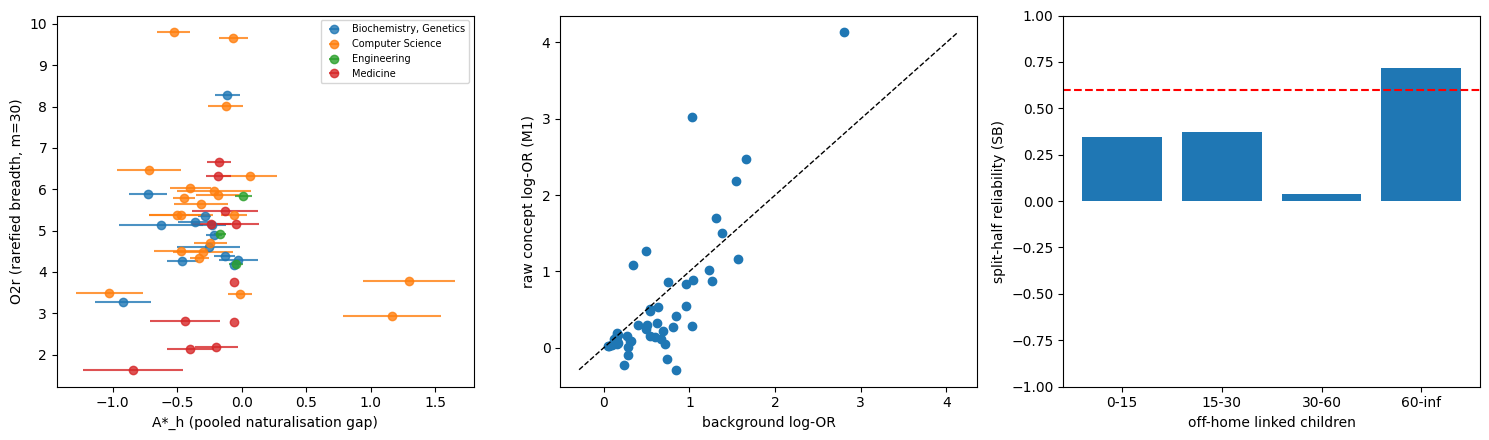

11:11:43|INFO   |SURVIVES=False clauses={'delta_rho_ge_0.10_and_ci_low_gt_0': False, 'positive_groups_ge_3_of_4': False, 'reliability_ge_0.6': False, 'size_abs_rho_le_0.6': True} runtime 355s


In [30]:
# ---------------- outputs
D["oof_B5"] = main_cmp["oof_B"]; D["oof_B5_plus_A_h"] = main_cmp["oof_BC"]
deviations = [
    "D1 (plan): availability-cancelling MH table with home children as the control row, not the literal off-home-only GLMM (T0 test ii demonstrates the drift).",
    "D2 (plan): two-stage crossed random-effects pooling (REML-EB via Henderson MME) with PyMC NUTS and a one-stage BinomialBayesMixedGLM as checks.",
    "D8 (new, credit-bound): the shared OpenAlex daily pool (10,000 credits, five artifacts) was at 2,098 at start and fell below the 1,000-credit sibling floor after 139 own credits; OpenAlex S0 is complete only for yearly counts (all 78 concepts) and for field distributions of 11 dev concepts (OpenAlex topic fields). The count-based parts of S0 (t0, newborn, O1, O3, log early volume, early growth) follow S0 exactly.",
    "D9 (new, zero-credit data): concept papers (title/abstract phrase search), their citation lists (lineage links) and field labels come from the Semantic Scholar Graph API. Field labels are fractional memberships over the 23 S2 fields of study (s2-fos-model, a title/abstract text classifier, hence not circular for citation flows) instead of 26-field OpenAlex venue labels; home, dev restriction (sealed = home outside CS/Engineering/Biology/Medicine), O2r, R_j and the field-based B5 terms are computed on these S2 labels for every dev concept, and cross-validated against the OpenAlex S0 where it exists.",
    "D10 (new): background references come from FREE OpenAlex singleton GETs (/works/W<MAG>, cost 0 verified from response headers; the client aborts if a singleton is ever charged) and their fields from S2 via MAG ids.",
    "D4' (plan D4 adapted): all phrase-matched early papers are downloaded (up to 25,000); citation lists are pulled for a seeded uniform sample of at most 1,500 parents per concept (parent_thin), which thins links linearly and cancels in the odds ratios.",
    "D3' (plan D3): local exact/lemma confirmation runs on title + abstract; S2 elides most abstracts, so papers whose abstract is elided and whose title lacks the phrase are kept as 'unverifiable' (S2 phrase index) and only papers with an available abstract lacking the phrase are rejected; exact_share = confirmed/(confirmed+rejected).",
    "D12: O3 = peak count in t0+3..t0+8 >= 2 x mean(t0+7, t0+8) (argmax taken over that range, as in the plan).",
]
screen_result = {
    "candidate": "L_naturalisation_gap", "n_used": int(len(D)), "n_dev_concepts": len(names),
    "n_dropped_by_reason": dr["reason"].str.split(":").str[0].str.split(" ").str[0].value_counts().to_dict() if len(dr) else {},
    "delta_rho": main_cmp["delta"], "ci90": main_cmp["ci90"], "rho_B": main_cmp["metric_B"], "rho_BC": main_cmp["metric_BC"],
    "refit_bootstrap": main_cmp["refit_bootstrap"], "per_group": main_cmp["per_group"],
    "n_pos_groups": main_cmp["n_pos_groups"], "reliability": rel, "reliability_vs_n": rel_n,
    "eligibility_threshold": elig_floor, "eligible_subset_result": sub_results.get("eligible"),
    "sensitivity": {"newborn_only": sub_results.get("newborn_only"), "full_parent_sample": sub_results.get("full_parent_sample"),
                    "O2r_m50": sens_m.get("O2r_m50"), "O2r_m20": sens_m.get("O2r_m20"),
                    "B5_plus_offhome_vol_growth": {k: v for k, v in size_adj.items() if not k.startswith("oof")}},
    "size_corr": size,
    "delta_auc_O1": {k: v for k, v in res_auc["O1"].items() if not k.startswith("oof")},
    "delta_auc_O3": {k: v for k, v in res_auc["O3"].items() if not k.startswith("oof")},
    "outcome_prevalence": {"O1": float(D["O1"].mean()), "O3": float(D["O3"].mean()), "n": int(len(D))},
    "hurdle": {k: v for k, v in hurdle.items() if not k.startswith("oof")} if hurdle else "single class (all N_late >= 30)",
    "field_level": field_level, "M1": M1, "agreement": agree, "s0_cross_source": xval,
    "pooling": {"engine": fit.engine, "tau_c": fit.tau_c, "tau_cj": fit.tau_cj, "beta": dict(zip(fit.fields_x, fit.beta)),
                "n_cells": len(units)},
    "pymc_check": pymc_check, "glmm_check": glmm,
    "survives": survives, "clause_results": clauses, "secondary_rules_exploratory": secondary_rules,
    "candidate_comparison_table": cand_table,
    "credits_used": data["credits"]["credits_used"], "openalex_calls": data["credits"]["openalex_calls"],  # original: from logs/credits.csv
    "runtime_s": time.time() - t_start, "deviations": deviations,
}
screen_result = jsonable(screen_result)
out.drop(columns=[]).to_csv(RES / "outcomes.csv", index=False)
if len(oa_rows):
    oa_rows.drop(columns=["yc"]).to_csv(RES / "outcomes_openalex_s0.csv", index=False)
fo.to_csv(RES / "field_outcomes.csv", index=False)
feat.to_csv(RES / "features.csv", index=False)
ff.to_csv(RES / "field_features.csv", index=False)
dr.to_csv(RES / "dropped.csv", index=False)
D.to_csv(RES / "screen_table.csv", index=False)
(RES / "screen_result.json").write_text(json.dumps(screen_result, indent=1))
write_method_out(D, FL, screen_result)
try:
    figures(D, feat, rel_n)
except Exception as e:
    logger.error(f"figures failed: {e!r}")
logger.info(f"SURVIVES={survives} clauses={ {k: v['pass'] for k, v in clauses.items()} } "
            f"runtime {time.time()-t_start:.0f}s")

## Results summary and visualisation
The first table puts the demo's headline numbers next to the full run's `screen_result.json`. With the default
(original) config they match exactly. With a reduced config, the bootstrap CIs, the reliability and $A^*_h$ itself
(via the stage-1 variances) move a little.

The figures show:
- the out-of-fold predictions of B5 and of B5 + $A^*_h$ against O2r;
- $\Delta\rho$ with its 90% CI for every exploratory candidate;
- the per-group $\Delta\rho$ of $A^*_h$;
- reliability against the number of off-home children.

                             statistic this notebook full run (screen_result.json)
                         concepts used            48                            48
           rho_B5 (LOGO Spearman, O2r)         0.834                         0.834
                            rho_B5+A_h         0.828                         0.828
                             Delta-rho        -0.006                        -0.006
                    Delta-rho CI90 low        -0.034                        -0.034
                   Delta-rho CI90 high         0.017                         0.017
       positive left-out groups (of 4)             0                             0
       split-half reliability A_h (SB)         0.584                         0.584
           |rho| with log early volume         0.145                         0.145
               |rho| with early growth         0.177                         0.177
                            REML tau_c         0.294                         0.294
    

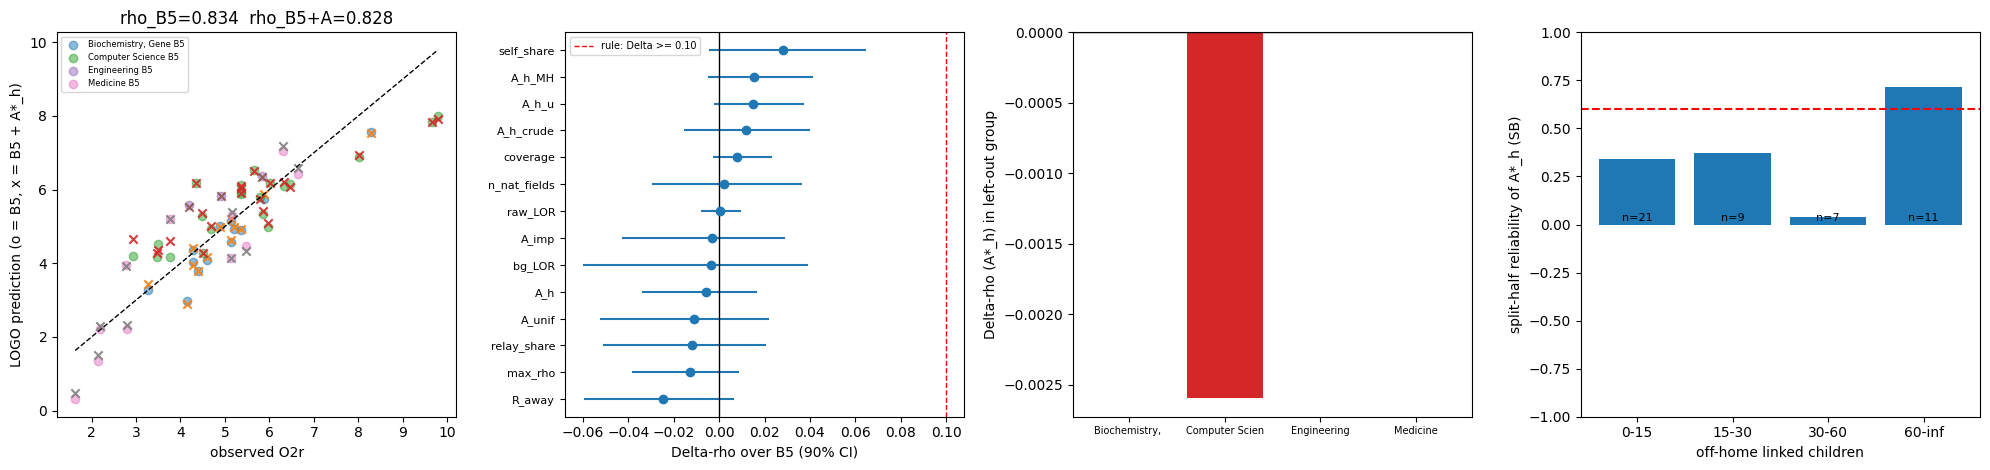

In [31]:
ref = data["reference_results_full_run"]
rel_A = (rel.get("A_h") or {}).get("reliability_SB")
summary = pd.DataFrame([
    ("concepts used", len(D), ref["n_used"]),
    ("rho_B5 (LOGO Spearman, O2r)", main_cmp["metric_B"], ref["rho_B"]),
    ("rho_B5+A_h", main_cmp["metric_BC"], ref["rho_BC"]),
    ("Delta-rho", main_cmp["delta"], ref["delta_rho"]),
    ("Delta-rho CI90 low", main_cmp["ci90"][0], ref["ci90"][0]),
    ("Delta-rho CI90 high", main_cmp["ci90"][1], ref["ci90"][1]),
    ("positive left-out groups (of 4)", main_cmp["n_pos_groups"], ref["n_pos_groups"]),
    ("split-half reliability A_h (SB)", rel_A, ref["reliability_A_h"]),
    ("|rho| with log early volume", abs(size["vol"]), abs(ref["size_corr"]["vol"])),
    ("|rho| with early growth", abs(size["growth"]), abs(ref["size_corr"]["growth"])),
    ("REML tau_c", fit.tau_c, ref["pooling"]["tau_c"]),
    ("REML tau_cj", fit.tau_cj, ref["pooling"]["tau_cj"]),
    ("O1 Delta-AUC", res_auc["O1"]["delta"], ref["delta_auc_O1"]),
    ("field-level Delta-AUC (rho*_cj -> R_j)", field_level["delta"] if field_level else np.nan, ref["field_level_delta"]),
    ("M1 R^2 raw LOR ~ background LOR", M1["R2"] if M1 else np.nan, ref["M1"]["R2"]),
    ("survives pre-registered rule", survives, ref["survives"]),
], columns=["statistic", "this notebook", "full run (screen_result.json)"])
pd.set_option("display.width", 160)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\nPer left-out group (O2r, ridge):")
print(pd.DataFrame(main_cmp["per_group"]).T.to_string(float_format=lambda x: f"{x:.3f}"))

ct = pd.DataFrame({k: {"delta_rho": v["delta_rho"], "ci_lo": v["ci90"][0], "ci_hi": v["ci90"][1],
                       "n_pos_groups": v["n_pos_groups"], "spearman_O2r": v["spearman_with_O2r"],
                       "reliability": v["reliability_SB"]} for k, v in cand_table.items()}).T.sort_values("delta_rho")
print("\nExploratory candidates vs B5 (none should beat it):")
print(ct.to_string(float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(1, 4, figsize=(20, 4.8))
for g, sub in D.groupby("dev_group"):
    ax[0].scatter(sub["O2r"], sub["oof_B5"], marker="o", alpha=.5, label=f"{g[:18]} B5")
    ax[0].scatter(sub["O2r"], sub["oof_B5_plus_A_h"], marker="x", alpha=.9)
lo, hi = D["O2r"].min(), D["O2r"].max()
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("observed O2r"); ax[0].set_ylabel("LOGO prediction (o = B5, x = B5 + A*_h)")
ax[0].set_title(f"rho_B5={main_cmp['metric_B']:.3f}  rho_B5+A={main_cmp['metric_BC']:.3f}"); ax[0].legend(fontsize=6)
yy = np.arange(len(ct))
ax[1].errorbar(ct["delta_rho"], yy, xerr=[ct["delta_rho"] - ct["ci_lo"], ct["ci_hi"] - ct["delta_rho"]], fmt="o")
ax[1].set_yticks(yy); ax[1].set_yticklabels(ct.index, fontsize=8)
ax[1].axvline(0, color="k", lw=1); ax[1].axvline(0.10, color="r", ls="--", lw=1, label="rule: Delta >= 0.10")
ax[1].set_xlabel("Delta-rho over B5 (90% CI)"); ax[1].legend(fontsize=7)
pg = main_cmp["per_group"]
ax[2].bar([g[:14] for g in pg], [pg[g]["delta"] for g in pg], color=["tab:green" if pg[g]["delta"] > 0 else "tab:red" for g in pg])
ax[2].axhline(0, color="k", lw=1); ax[2].set_ylabel("Delta-rho (A*_h) in left-out group"); ax[2].tick_params(axis="x", labelsize=7)
if rel_n:
    ax[3].bar([b["bin"] for b in rel_n], [b["reliability_SB"] if b["reliability_SB"] is not None else np.nan for b in rel_n])
    for i, b in enumerate(rel_n):
        ax[3].text(i, 0.02, f"n={b['n_concepts']}", ha="center", fontsize=8)
ax[3].axhline(0.6, color="r", ls="--"); ax[3].set_ylim(-1, 1)
ax[3].set_xlabel("off-home linked children"); ax[3].set_ylabel("split-half reliability of A*_h (SB)")
fig.tight_layout(); plt.show()